# 🗃️ DVC — Version Your Data, Models, and Pipelines Like Code

> **What you'll learn:** why Git alone can't version datasets and models, how DVC keeps small pointer files in Git and the real bytes in a content-addressable cache, how to push/pull data to a remote, go back to an old dataset version, build a cached ML pipeline with `dvc.yaml`, compare params and metrics across commits, and run experiments — with **every command actually executed** in a temporary Git repository.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate (🔴 experiments and pipeline design) |
| **Time** | ~3 hours to read and run, +1.5 hours for exercises and the project |
| **Prerequisites** | [MLflow](01_MLflow.ipynb) (experiment tracking) · [Virtual Environments & Packaging](../00_Foundations/04_Virtual_Env_and_Packaging.ipynb) (running commands, Git basics) · [scikit-learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) |
| **Tested with** | Python 3.12 · dvc 3.67 · git 2.48 · scikit-learn 1.9 · pandas 3.0 |
| **Interview relevance** | ⭐⭐ Medium–High — "how do you reproduce a model from 6 months ago?", data versioning design, pipeline caching, DVC vs Git LFS vs MLflow |

## 🤔 What Is DVC?

Think of a big public library.

- The **catalogue** is small: one card per book saying *which* book it is and *where* it sits. You can photocopy the whole catalogue in seconds.
- The **warehouse** is huge: it holds the actual books.

**DVC (Data Version Control)** gives your ML project the same split:

- **Git is the catalogue.** It stores tiny text files (called **metafiles**, e.g. `data.csv.dvc`) that say *"this project uses the file whose fingerprint is `5afc23…`"*.
- **The DVC cache and remote storage are the warehouse.** They store the real bytes of datasets and models, filed under that fingerprint.

A **fingerprint** here is a **hash**: a short string computed from a file's contents (DVC uses MD5). Same bytes → same hash; change one byte → a completely different hash. Storage organised by hash is called **content-addressable storage**.

```
          Git repository (small, fast)                    DVC cache / remote (big)
  ┌─────────────────────────────────────┐          ┌──────────────────────────────────┐
  │ train.py, params.yaml, dvc.yaml     │          │ files/md5/5a/fc23b9…  ← data v1  │
  │ data.csv.dvc   md5: 5afc23b9…  ─────┼────────▶ │ files/md5/9e/01d7a4…  ← data v2  │
  │ dvc.lock       (pipeline hashes)    │          │ files/md5/c3/77e0b2…  ← model    │
  └─────────────────────────────────────┘          └──────────────────────────────────┘
```

On top of that, DVC is a **pipeline runner** (like `make` for ML): it re-runs only the steps whose inputs changed, and it can compare **parameters** and **metrics** across Git commits and experiments.

## 🎯 Why It Matters

- **Reproducibility is a job requirement.** Regulators, auditors, and your future self ask: *"exactly which data and code produced the model in production?"* With DVC the answer is one Git commit.
- **Data changes more often than code.** New labels arrive, bugs in feature code get fixed, a vendor re-sends a corrected file. Without versioning you can't tell whether a metric changed because of the model or the data.
- **Teams share data safely.** `git clone` + `dvc pull` gives a new teammate the exact bytes, instead of "grab the latest CSV from the shared drive".
- **Pipelines save compute.** Stage caching skips expensive steps that haven't changed.
- **In interviews** this shows up in MLOps and ML system design rounds: *"How would you version a 2 TB dataset?"*, *"Why did your pipeline rerun training when only the evaluation code changed?"*, *"DVC or Git LFS or MLflow artifacts?"* This notebook gives you real, tested answers.

## ✅ By the End You Can

- [ ] Explain why Git alone struggles with datasets and models, with numbers
- [ ] Track files and folders with `dvc add`, and explain `.dvc` files, hashes, and the cache layout
- [ ] Share data through a remote with `dvc push` / `dvc pull`, and restore an older dataset version
- [ ] Write a multi-stage `dvc.yaml` pipeline with deps, outs, params, metrics, and plots — and predict which stages `dvc repro` will rerun
- [ ] Compare runs with `dvc params diff`, `dvc metrics diff`, and `dvc exp show`, then promote the best experiment
- [ ] Build a tiny content-addressable cache that produces the same hashes DVC does

## 📋 Table of Contents

1. [Why Git Alone Fails for Data and Models](#1.-Why-Git-Alone-Fails-for-Data-and-Models-🟢)
2. [DVC's Model: Metafiles in Git, Content in a Cache](#2.-DVC's-Model:-Metafiles-in-Git,-Content-in-a-Cache-🟢)
3. [Tracking a Dataset with dvc add](#3.-Tracking-a-Dataset-with-dvc-add-🟢)
4. [Hashes, the Cache, and Tracking Folders](#4.-Hashes,-the-Cache,-and-Tracking-Folders-🟡)
5. [Remotes: dvc push and dvc pull](#5.-Remotes:-dvc-push-and-dvc-pull-🟢)
6. [Time Travel: Going Back to an Older Dataset](#6.-Time-Travel:-Going-Back-to-an-Older-Dataset-🟡)
7. [Pipelines in dvc.yaml](#7.-Pipelines-in-dvc.yaml-🟡)
8. [dvc repro and Stage Caching](#8.-dvc-repro-and-Stage-Caching-🟡)
9. [Parameters: params.yaml and dvc params diff](#9.-Parameters:-params.yaml-and-dvc-params-diff-🟡)
10. [Metrics and Plots](#10.-Metrics-and-Plots-🟡)
11. [Experiments: dvc exp run, show, apply, branch](#11.-Experiments:-dvc-exp-run,-show,-apply,-branch-🔴)
12. [DVC in CI](#12.-DVC-in-CI-🟡)
13. [DVC vs Git LFS vs MLflow Artifacts vs lakeFS](#13.-DVC-vs-Git-LFS-vs-MLflow-Artifacts-vs-lakeFS-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Versioned-4-Stage-House-Price-Pipeline) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

This notebook runs **real terminal commands** (`git …` and `dvc …`) through a small `run()` helper that prints `$ command` and the command's real output, like a terminal. Everything happens inside a **temporary folder** (shown as `$WORK`), so your own projects are never touched.

A few details worth knowing:

- **Git is required** (DVC stores its metafiles in Git). Check with `git --version`; install it by following [Git - Install](https://git-scm.com/install/) if it's missing.
- We call DVC as `python -m dvc …` using *this notebook's* Python, so it's always the DVC installed next to your libraries. In a terminal you'd just type `dvc …`.
- We put this Python's folder first on `PATH`, so `python src/train.py` inside a pipeline uses the same environment.
- `DVC_NO_ANALYTICS=1` turns off DVC's anonymous usage analytics for these commands.
- Each temp repo gets its own Git author (`user.name` / `user.email`), and your global Git config is ignored (`GIT_CONFIG_GLOBAL`), so settings like commit signing on your machine can't break the demos.

Data: scikit-learn's bundled **breast cancer** dataset (no download) for the concept sections, and the **California housing** dataset (a ~400 KB download, cached after the first run) for section 1 and the mini project.

In [1]:
# %pip install -q "dvc>=3.50" "scikit-learn>=1.5" "pandas>=2.2" pyyaml matplotlib

import hashlib
import importlib.metadata as md
import json
import os
import re
import shutil
import subprocess
import sys
import tempfile
import textwrap
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

GIT = shutil.which("git")
assert GIT, "Git is not installed — DVC needs Git. Install it from https://git-scm.com/downloads, then restart the kernel."

WORK_RAW = tempfile.mkdtemp(prefix="dvc_nb_")
WORK = Path(WORK_RAW).resolve()
HOME = str(Path.home())
OUTPUT_DIR = Path("_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
EMPTY_GITCONFIG = WORK / "empty.gitconfig"
EMPTY_GITCONFIG.write_text("")

os.environ["DVC_NO_ANALYTICS"] = "1"          # also for dvc.api calls made inside this kernel
ENV = {k: v for k, v in os.environ.items() if k not in {"VIRTUAL_ENV", "PYTHONPATH", "PYTHONHOME", "MPLBACKEND"}}
ENV.update(
    PATH=str(Path(sys.executable).parent) + os.pathsep + os.environ.get("PATH", ""),
    DVC_NO_ANALYTICS="1",
    GIT_CONFIG_GLOBAL=str(EMPTY_GITCONFIG),
    GIT_CONFIG_NOSYSTEM="1",
    NO_COLOR="1",
    COLUMNS="140",
    OMP_NUM_THREADS="4",      # keep each pipeline stage from grabbing every CPU core (faster on a busy laptop)
)


def short(text):
    """Make paths readable: temp folder → $WORK, home folder → ~."""
    text = str(text)
    for work in {str(WORK), WORK_RAW, "/private" + WORK_RAW}:
        text = text.replace(work, "$WORK")
    return text.replace(HOME, "~")


def run(cmd, cwd, check=True, show=True, max_lines=30, tail=False):
    """Run a command like a terminal: print `$ command`, its real output, and the exit code if non-zero."""
    cmd = [str(c) for c in cmd]
    start = time.perf_counter()
    result = subprocess.run(cmd, cwd=cwd, env=ENV, capture_output=True, text=True, timeout=900)
    result.seconds = time.perf_counter() - start
    result.output = re.sub(r"\x1b\[[0-9;?]*[A-Za-z]", "", result.stdout + result.stderr)    # colour + cursor codes
    if show:
        shown = ["dvc", *cmd[3:]] if cmd[1:3] == ["-m", "dvc"] else [Path(cmd[0]).name, *cmd[1:]]
        print("$", short(" ".join(shown)))
        lines = [line for line in result.output.rstrip().splitlines() if not re.match(r"^\s*[⠀-⣿]\s", line)]  # drop spinners
        lines = [line for i, line in enumerate(lines) if line.strip() or (i and lines[i - 1].strip())]  # squeeze blank runs
        hidden = len(lines) - max_lines
        if hidden > 0:
            lines = lines[-max_lines:] if tail else lines[:max_lines]
        if hidden > 0 and tail:
            print(f"  … ({hidden} earlier lines hidden)")
        for line in lines:
            print("  " + short(line))
        if hidden > 0 and not tail:
            print(f"  … ({hidden} more lines)")
        if result.returncode != 0:
            print(f"  [exit code {result.returncode}]")
    if check and result.returncode != 0:
        raise RuntimeError(f"command failed ({result.returncode}): {short(' '.join(cmd))}\n{short(result.output[-1500:])}")
    return result


def dvc(*args, cwd, **kwargs):
    return run([sys.executable, "-m", "dvc", *args], cwd=cwd, **kwargs)


def git(*args, cwd, **kwargs):
    return run([GIT, *args], cwd=cwd, **kwargs)


def new_repo(path, with_dvc=True):
    """Create a Git repo (+ DVC) with a local author, inside the temp folder."""
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    git("init", "-q", "-b", "main", cwd=path, show=False)
    git("config", "user.name", "DVC Learner", cwd=path, show=False)
    git("config", "user.email", "learner@example.com", cwd=path, show=False)
    if with_dvc:
        dvc("init", "-q", cwd=path, show=False)
    return path


def reset_to_head(repo):
    """Discard workspace changes (params, dvc.lock, metrics) and restore the committed outputs from the DVC cache."""
    git("checkout", "HEAD", "--", ".", cwd=repo, show=False)
    dvc("checkout", "--force", cwd=repo, show=False)


def write(path, text):
    """Create a file (and its folders) from an indented triple-quoted string."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(textwrap.dedent(text).lstrip("\n"))
    return path


def show_file(path, max_lines=40):
    lines = Path(path).read_text().splitlines()
    print(f"── {short(Path(path).name)} " + "─" * 40)
    for line in lines[:max_lines]:
        print("  " + short(line))
    if len(lines) > max_lines:
        print(f"  … ({len(lines) - max_lines} more lines)")


def stage_report(output):
    """Parse `dvc repro` / `dvc exp run` output into which stages ran, were skipped, or came from the run-cache."""
    return {
        "ran": re.findall(r"Running stage '([^']+)'", output),
        "skipped": re.findall(r"Stage '([^']+)' didn't change, skipping", output),
        "from run-cache": re.findall(r"Stage '([^']+)' is cached - skipping run", output),
    }


def _same(got, expected):
    if isinstance(expected, dict):
        return isinstance(got, dict) and got.keys() == expected.keys() and all(_same(got[k], expected[k]) for k in expected)
    if isinstance(expected, (list, tuple)):
        return isinstance(got, (list, tuple)) and len(got) == len(expected) and all(_same(g, e) for g, e in zip(got, expected))
    if isinstance(expected, float) and isinstance(got, (int, float)):
        return bool(np.isclose(got, expected, rtol=1e-6, atol=1e-9))
    return got == expected


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    assert _same(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")


git_version = run([GIT, "--version"], cwd=WORK, show=False).stdout.split()[2]
print(f"Python {sys.version.split()[0]} | dvc {md.version('dvc')} | git {git_version} | "
      f"scikit-learn {md.version('scikit-learn')} | pandas {pd.__version__}")
print(f"scratch folder: a new temporary directory named {WORK.name} (shown as $WORK)")

Python 3.12.11 | dvc 3.67.1 | git 2.48.1 | scikit-learn 1.9.1 | pandas 3.0.5
scratch folder: a new temporary directory named dvc_nb_ktoth4ys (shown as $WORK)


## 1. Why Git Alone Fails for Data and Models 🟢

Git was designed for source code: many small text files that change a few lines at a time. ML projects add two very different kinds of files:

| | Source code | Datasets | Model files |
|---|---|---|---|
| Typical size | KB | MB → TB | MB → GB |
| Change pattern | a few lines | rows appended / corrected | **every byte changes** after retraining |
| Diff-friendly? | yes | sometimes (CSV) | no (binary floats) |

Git keeps **every version of every file forever**, and `git clone` downloads all of that history. GitHub warns about files over 50 MiB and **blocks files over 100 MiB**.

Let's measure instead of claiming. We commit 5 versions of two real files to plain Git repos:
1. the California housing dataset as CSV, where 1% of rows get corrected in each version, and
2. the weights of a small neural network trained on it, saved after each training epoch (like checkpoints).

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing(as_frame=True).frame          # 20,640 real districts
print("California housing:", housing.shape)


def git_objects_mb(repo):
    git("gc", "-q", cwd=repo, show=False)                        # pack + delta-compress, the best case for Git
    return sum(p.stat().st_size for p in (repo / ".git" / "objects").rglob("*") if p.is_file()) / 1e6


csv_repo, weights_repo = new_repo(WORK / "git-csv", with_dvc=False), new_repo(WORK / "git-weights", with_dvc=False)
X_h = StandardScaler().fit_transform(housing.drop(columns="MedHouseVal"))
y_h = housing["MedHouseVal"].to_numpy()
mlp = MLPRegressor(hidden_layer_sizes=(256, 128), random_state=0)
data = housing.copy()
gen = np.random.default_rng(0)

rows = []
for version in range(1, 6):
    fix = gen.choice(len(data), size=len(data) // 100, replace=False)       # 1% of rows get corrected
    data.loc[fix, "AveOccup"] = data.loc[fix, "AveOccup"].round(1)
    data.to_csv(csv_repo / "housing.csv", index=False)
    mlp.partial_fit(X_h, y_h)                                              # one more epoch → every weight moves
    weights = np.concatenate([w.ravel() for w in mlp.coefs_ + mlp.intercepts_])
    np.save(weights_repo / "weights.npy", weights)
    for repo in (csv_repo, weights_repo):
        git("add", ".", cwd=repo, show=False)
        git("commit", "-q", "-m", f"version {version}", cwd=repo, show=False)
    rows.append({"version": version,
                 "csv file MB": (csv_repo / "housing.csv").stat().st_size / 1e6,
                 "csv .git MB": git_objects_mb(csv_repo),
                 "weights file MB": (weights_repo / "weights.npy").stat().st_size / 1e6,
                 "weights .git MB": git_objects_mb(weights_repo)})

growth = pd.DataFrame(rows).set_index("version").round(2)
print(growth)
last = growth.iloc[-1]
print(f"\nCSV    : 5 versions cost {last['csv .git MB']:.2f} MB in .git = {last['csv .git MB'] / last['csv file MB']:.1f}× one file "
      "(text compresses and deltas reasonably well)")
print(f"Weights: 5 versions cost {last['weights .git MB']:.2f} MB in .git = {last['weights .git MB'] / last['weights file MB']:.1f}× one file "
      "(binary floats that all change can't be delta-compressed)")

California housing: (20640, 9)


         csv file MB  csv .git MB  weights file MB  weights .git MB
version                                                            
1               1.89         0.71             0.28             0.27
2               1.89         0.71             0.28             0.54
3               1.89         0.72             0.28             0.81
4               1.88         0.72             0.28             1.09
5               1.88         0.73             0.28             1.36

CSV    : 5 versions cost 0.73 MB in .git = 0.4× one file (text compresses and deltas reasonably well)
Weights: 5 versions cost 1.36 MB in .git = 4.9× one file (binary floats that all change can't be delta-compressed)


Scale those ratios up: a 2 GB model retrained weekly adds roughly 2 GB of history *per week* to every clone, and a single file over 100 MiB can't be pushed to GitHub at all. Git also can't answer ML questions like *"which data produced this model?"* or *"skip training if nothing changed"*.

> 💡 **Interview angle:** "Why not just commit data to Git?" — Git stores every version forever and every clone downloads it; binary model files don't delta-compress; hosting limits block large files (GitHub: 100 MiB); and Git has no concept of pipelines or cache reuse. Keep *pointers* in Git and bytes in object storage.

## 2. DVC's Model: Metafiles in Git, Content in a Cache 🟢

Four places matter:

| Place | What lives there | Tracked by Git? |
|---|---|---|
| **Workspace** | the files you see: `data/train.csv`, `models/model.pkl` | ❌ (DVC adds them to `.gitignore`) |
| **Metafiles** | `*.dvc` files, `dvc.yaml`, `dvc.lock`, `params.yaml` — small text with hashes | ✅ |
| **Cache** `.dvc/cache/` | one copy of every version of every tracked file, named by hash | ❌ |
| **Remote** (S3, GCS, Azure, SSH, a shared folder…) | a copy of the cache that the team shares | ❌ |

```
  workspace ──dvc add / dvc commit──▶ cache ──dvc push──▶ remote
  workspace ◀──── dvc checkout ────── cache ◀─dvc fetch── remote      (dvc pull = fetch + checkout)
```

`dvc init` sets this up inside an existing Git repo:

In [3]:
project = new_repo(WORK / "project", with_dvc=False)
dvc("init", cwd=project)
print("\ncreated:", sorted(p.name for p in (project / ".dvc").iterdir()), "+ .dvcignore")
show_file(project / ".dvc" / ".gitignore")
git("status", "--short", cwd=project)
git("commit", "-q", "-m", "Initialize DVC", cwd=project);

$ dvc init
  Initialized DVC repository.
  
  You can now commit the changes to git.
  
  What's next?
  ------------
  - Check out the documentation: <https://dvc.org/doc>
  - Get help and share ideas: <https://dvc.org/chat>
  - Star us on GitHub: <https://github.com/treeverse/dvc>

created: ['.gitignore', 'config', 'tmp'] + .dvcignore
── .gitignore ────────────────────────────────────────
  /config.local
  /tmp
  /cache
$ git status --short
  A  .dvc/.gitignore
  A  .dvc/config
  A  .dvcignore
$ git commit -q -m Initialize DVC


`dvc init` staged its own small files for Git: `.dvc/config` (settings, e.g. remotes), `.dvc/.gitignore` (keeps the cache and temp files out of Git) and `.dvcignore` (patterns DVC should skip, like `.gitignore`).

> 💡 **Interview angle:** "What does DVC store in Git?" — only metafiles: `.dvc` files, `dvc.yaml`/`dvc.lock`, params and small metrics files, and `.dvc/config`. The data lives in the cache and remote, addressed by hash.

## 3. Tracking a Dataset with dvc add 🟢

`dvc add <file>` does four things:
1. computes the file's **MD5 hash**,
2. moves the content into the cache at `.dvc/cache/files/md5/<first 2 chars>/<remaining 30 chars>` and links it back into the workspace,
3. writes a small **`<file>.dvc` metafile** with the hash, size, and path,
4. adds the file to `.gitignore`, so Git never commits the data itself.

Our dataset: the first 400 rows of the breast cancer dataset — pretend it's the data we had in January.

In [4]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True).frame                  # 569 real patients, 30 features + target
(project / "data").mkdir()
cancer.iloc[:400].to_csv(project / "data" / "breast_cancer.csv", index=False)

dvc("add", "data/breast_cancer.csv", cwd=project)
show_file(project / "data" / "breast_cancer.csv.dvc")
show_file(project / "data" / ".gitignore")
print("\ncache files:", [short(p.relative_to(project)) for p in (project / ".dvc" / "cache").rglob("*") if p.is_file()])
git("status", "--short", cwd=project);

$ dvc add data/breast_cancer.csv
  To track the changes with git, run:
  
  	git add data/.gitignore data/breast_cancer.csv.dvc
  
  To enable auto staging, run:
  
  	dvc config core.autostage true
── breast_cancer.csv.dvc ────────────────────────────────────────
  outs:
  - md5: 2c0ae313d960d308e5d1a2e7aa9fb0f3
    size: 85510
    hash: md5
    path: breast_cancer.csv
── .gitignore ────────────────────────────────────────
  /breast_cancer.csv

cache files: ['.dvc/cache/files/md5/2c/0ae313d960d308e5d1a2e7aa9fb0f3']
$ git status --short
  ?? data/


In [5]:
git("add", "data/breast_cancer.csv.dvc", "data/.gitignore", cwd=project)
git("commit", "-q", "-m", "Track January data with DVC", cwd=project)
git("tag", "data-v1", cwd=project)
git("log", "--oneline", cwd=project);

$ git add data/breast_cancer.csv.dvc data/.gitignore
$ git commit -q -m Track January data with DVC
$ git tag data-v1
$ git log --oneline
  32470b7 Track January data with DVC
  720d308 Initialize DVC


The `.dvc` file is plain YAML: `md5` is the fingerprint, `size` is in bytes, and `hash: md5` records the hashing scheme (DVC 3 hashes the raw bytes; DVC 2 used a slightly different text-normalised MD5, which is why old projects show no `hash:` line).

### ✍️ Your Turn

Prove the `.dvc` file isn't magic: compute the MD5 of `data/breast_cancer.csv` yourself with `hashlib` and store the hex string in `my_md5`.

In [6]:
dvc_meta = yaml.safe_load((project / "data" / "breast_cancer.csv.dvc").read_text())
my_md5 = None  # TODO: hashlib.md5(...).hexdigest() of the file's bytes
check("my_md5", my_md5, dvc_meta["outs"][0]["md5"], hint="hashlib.md5((project / 'data' / 'breast_cancer.csv').read_bytes()).hexdigest()")

⏳ my_md5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dvc_meta = yaml.safe_load((project / "data" / "breast_cancer.csv.dvc").read_text())
my_md5 = hashlib.md5((project / "data" / "breast_cancer.csv").read_bytes()).hexdigest()
check("my_md5", my_md5, dvc_meta["outs"][0]["md5"])
```
For multi-GB files, hash in chunks (`for block in iter(lambda: f.read(1 << 20), b""): h.update(block)`) so you never load the whole file into memory.
</details>

> 💡 **Interview angle:** "What happens when you run `dvc add`?" — hash the file, move it into the content-addressable cache, link it back, write a `.dvc` pointer, and gitignore the data. You then `git commit` the pointer.

## 4. Hashes, the Cache, and Tracking Folders 🟡

**Deduplication.** Because files are stored by hash, identical content is stored once, no matter how many paths or versions point to it.

**Folders.** `dvc add some_folder/` hashes every file, then writes a small JSON **listing** (`[{"md5": …, "relpath": …}, …]`) into the cache. The listing's own hash ends in **`.dir`**. When one file in a 100,000-file folder changes, only that file and a new listing are added to the cache.

Let's track a folder of monthly data deliveries, then add a new month:

In [7]:
deliveries = project / "data" / "deliveries"
deliveries.mkdir()
cancer.iloc[:200].to_csv(deliveries / "batch_01.csv", index=False)
cancer.iloc[200:400].to_csv(deliveries / "batch_02.csv", index=False)


def cache_objects(repo):
    return sorted(p for p in (repo / ".dvc" / "cache" / "files" / "md5").rglob("*") if p.is_file())


before = len(cache_objects(project))
dvc("add", "data/deliveries", cwd=project)
show_file(project / "data" / "deliveries.dvc")
dir_md5 = yaml.safe_load((project / "data" / "deliveries.dvc").read_text())["outs"][0]["md5"]
listing_path = project / ".dvc" / "cache" / "files" / "md5" / dir_md5[:2] / dir_md5[2:]
print("\nthe .dir listing stored in the cache:\n ", listing_path.read_text())
print(f"cache objects: {before} → {len(cache_objects(project))}")

$ dvc add data/deliveries
  To track the changes with git, run:
  
  	git add data/.gitignore data/deliveries.dvc
  
  To enable auto staging, run:
  
  	dvc config core.autostage true
── deliveries.dvc ────────────────────────────────────────
  outs:
  - md5: 9aa3dd7cb5af483cba2ad9af375adc22.dir
    size: 86002
    nfiles: 2
    hash: md5
    path: deliveries

the .dir listing stored in the cache:
  [{"md5": "c3efd18e80f1619bc3f6c82d0aa00942", "relpath": "batch_01.csv"}, {"md5": "588b4ab1fbe440a662979a91a8d545a8", "relpath": "batch_02.csv"}]
cache objects: 1 → 4


In [8]:
cancer.iloc[400:].to_csv(deliveries / "batch_03.csv", index=False)       # a new month arrives
before = len(cache_objects(project))
dvc("status", cwd=project)
dvc("add", "data/deliveries", cwd=project, show=False)
added = len(cache_objects(project)) - before
print(f"re-added the folder: {added} new cache objects (1 new file + 1 new .dir listing) — the 2 old files were reused")
git("add", "data/deliveries.dvc", "data/.gitignore", cwd=project, show=False)
git("commit", "-q", "-m", "Track monthly deliveries", cwd=project, show=False)
dvc("config", "cache.type", cwd=project, check=False);

$ dvc status
  data/deliveries.dvc:
  	changed outs:
  		modified:           data/deliveries


re-added the folder: 2 new cache objects (1 new file + 1 new .dir listing) — the 2 old files were reused


$ dvc config cache.type


**How does the cache get back into the workspace?** Through the **link type** (`cache.type`). The default is `reflink,copy`: use a copy-on-write *reflink* where the filesystem supports it (APFS on macOS, Btrfs, XFS) and fall back to a full copy otherwise (the empty result above means "default"). `hardlink`/`symlink` save disk space on huge datasets but make workspace files read-only links into the cache — edit them in place and you corrupt the cache, so DVC protects them.

### ✍️ Your Turn

Read the `.dir` listing (`listing_path`) and return the MD5 that DVC recorded for `batch_02.csv`. (Hint: the listing is JSON.)

In [9]:
batch_02_md5 = None  # TODO: parse listing_path.read_text() and find the entry whose relpath is "batch_02.csv"
check("batch_02_md5", batch_02_md5, hashlib.md5((deliveries / "batch_02.csv").read_bytes()).hexdigest(),
      hint="json.loads(...) gives a list of dicts with keys 'md5' and 'relpath'.")

⏳ batch_02_md5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
entries = json.loads(listing_path.read_text())
batch_02_md5 = next(e["md5"] for e in entries if e["relpath"] == "batch_02.csv")
check("batch_02_md5", batch_02_md5, hashlib.md5((deliveries / "batch_02.csv").read_bytes()).hexdigest())
```
</details>

> 💡 **Interview angle:** "How does DVC handle a folder with a million images when one image changes?" — per-file hashes plus a `.dir` listing: only the changed file and a new listing are stored and pushed; everything else is deduplicated by hash.

## 5. Remotes: dvc push and dvc pull 🟢

The cache lives on *your* disk. A **remote** is shared storage the whole team (and CI) can reach. DVC supports S3, Google Cloud Storage, Azure Blob, SSH, HDFS, WebDAV, and plain directories (a mounted NFS share, a USB drive — or, here, a folder that stands in for a bucket).

A remote has the same `files/md5/xx/…` layout as the cache, so a local-directory remote behaves exactly like S3, just without credentials.

In [10]:
remote_dir = WORK / "dvc-remote"                    # stand-in for s3://my-bucket/dvc-store
remote_dir.mkdir()
dvc("remote", "add", "-d", "storage", remote_dir, cwd=project)
show_file(project / ".dvc" / "config")
dvc("push", cwd=project)
print("objects now in the remote:", len([p for p in remote_dir.rglob("*") if p.is_file()]))
dvc("status", "--cloud", cwd=project)
git("add", ".dvc/config", cwd=project, show=False)
git("commit", "-q", "-m", "Add shared DVC remote", cwd=project, show=False);

$ dvc remote add -d storage /private$WORK/dvc-remote
  Setting 'storage' as a default remote.
── config ────────────────────────────────────────
  [core]
      remote = storage
  ['remote "storage"']
      url = /private$WORK/dvc-remote


$ dvc push
  5 files pushed
objects now in the remote: 5


$ dvc status --cloud
  Cache and remote 'storage' are in sync.


**A cloud remote is the same two commands.** Let's really add an S3-style remote to see the config DVC writes (we remove it right after; nothing is uploaded, and talking to S3 would need the `dvc-s3` plugin: `pip install "dvc[s3]"`).

In [11]:
dvc("remote", "add", "cloud-example", "s3://my-bucket/dvc-store", cwd=project)
dvc("remote", "modify", "cloud-example", "region", "us-east-1", cwd=project)
show_file(project / ".dvc" / "config")
dvc("remote", "remove", "cloud-example", cwd=project);

$ dvc remote add cloud-example s3://my-bucket/dvc-store


$ dvc remote modify cloud-example region us-east-1
── config ────────────────────────────────────────
  [core]
      remote = storage
  ['remote "storage"']
      url = /private$WORK/dvc-remote
  ['remote "cloud-example"']
      url = s3://my-bucket/dvc-store
      region = us-east-1


$ dvc remote remove cloud-example


Credentials never belong in `.dvc/config` (it's committed). Put them in the **git-ignored** `.dvc/config.local`, or rely on the cloud SDK's normal credential chain (env vars, `~/.aws/credentials`, instance roles):

```bash
dvc remote add -d storage s3://my-bucket/dvc-store          # committed: where
dvc remote modify --local storage profile ml-team            # not committed: who (AWS profile name)
dvc remote add -d gcs gs://my-bucket/dvc-store
dvc remote modify --local gcs credentialpath /secure/sa.json # Google service-account key
```

**The teammate test.** A new colleague clones the Git repo. They get code and metafiles — but no data — until they `dvc pull`:

In [12]:
teammate = WORK / "teammate"
git("clone", "-q", project, teammate, cwd=WORK)
print("after git clone, data/ contains:", sorted(p.name for p in (teammate / "data").iterdir()))
dvc("pull", cwd=teammate)
same = hashlib.md5((teammate / "data" / "breast_cancer.csv").read_bytes()).hexdigest() == dvc_meta["outs"][0]["md5"]
print("teammate's breast_cancer.csv is byte-identical to ours:", same)

$ git clone -q /private$WORK/project /private$WORK/teammate
after git clone, data/ contains: ['.gitignore', 'breast_cancer.csv.dvc', 'deliveries.dvc']


$ dvc pull
  A       data/deliveries/
  A       data/breast_cancer.csv
  5 files fetched and 4 files added
teammate's breast_cancer.csv is byte-identical to ours: True


> 💡 **Interview angle:** "How does a new team member get the data?" — `git clone` then `dvc pull` (= `dvc fetch` from the remote into the cache + `dvc checkout` into the workspace). Push after every commit that changes tracked data, ideally enforced in CI or a `pre-push` hook (`dvc install`).

## 6. Time Travel: Going Back to an Older Dataset 🟡

More patients arrive: the dataset grows from 400 to 569 rows. We `dvc add` again, which updates the hash in the `.dvc` file, and commit that as a new version.

In [13]:
cancer.to_csv(project / "data" / "breast_cancer.csv", index=False)
dvc("status", cwd=project)
dvc("add", "data/breast_cancer.csv", cwd=project, show=False)
git("add", "data/breast_cancer.csv.dvc", cwd=project, show=False)
git("commit", "-q", "-m", "Data v2: 569 patients", cwd=project, show=False)
git("tag", "data-v2", cwd=project, show=False)
dvc("push", cwd=project, show=False)
dvc("diff", "data-v1", "data-v2", cwd=project);

$ dvc status
  data/breast_cancer.csv.dvc:
  	changed outs:
  		modified:           data/breast_cancer.csv


$ dvc diff data-v1 data-v2
  Added:
      data/deliveries/
      data/deliveries/batch_01.csv
      data/deliveries/batch_02.csv
      data/deliveries/batch_03.csv
  
  Modified:
      data/breast_cancer.csv
  
  files summary: 3 added, 1 modified


There are three ways to get the old data back:

| Goal | Command |
|---|---|
| Put an old version **in the workspace** | `git checkout data-v1 -- data/breast_cancer.csv.dvc` then `dvc checkout data/breast_cancer.csv.dvc` |
| Check out **everything** (code + data) at a commit | `git checkout data-v1` then `dvc checkout` |
| **Read** an old version from Python without touching the workspace | `dvc.api.read(path, repo=..., rev="data-v1")` / `dvc.api.open(...)` |
| Download a file from **another** DVC repo | `dvc get <repo-url> <path> --rev <tag>` |

In [14]:
def n_rows():
    return len(pd.read_csv(project / "data" / "breast_cancer.csv"))


print("today:", n_rows(), "rows")
git("checkout", "data-v1", "--", "data/breast_cancer.csv.dvc", cwd=project)
dvc("checkout", "data/breast_cancer.csv.dvc", cwd=project)
print("after going back to data-v1:", n_rows(), "rows")

git("checkout", "HEAD", "--", "data/breast_cancer.csv.dvc", cwd=project, show=False)
dvc("checkout", "data/breast_cancer.csv.dvc", cwd=project, show=False)
print("back to HEAD:", n_rows(), "rows")

today: 569 rows
$ git checkout data-v1 -- data/breast_cancer.csv.dvc


$ dvc checkout data/breast_cancer.csv.dvc
  M       data/breast_cancer.csv
after going back to data-v1: 400 rows


back to HEAD: 569 rows


### ✍️ Your Turn

Without touching the workspace, use `dvc.api.read` to load `data/breast_cancer.csv` **as it was at tag `data-v1`**, and store its number of rows in `rows_at_v1`.

In [15]:
import io

from dvc import api as dvc_api   # (a plain `import dvc.api` would overwrite our dvc() helper's name)

rows_at_v1 = None  # TODO: dvc_api.read("data/breast_cancer.csv", repo=str(project), rev="data-v1") → pd.read_csv(io.StringIO(...))
check("rows_at_v1", rows_at_v1, 400, hint="dvc_api.read returns the file's text; wrap it in io.StringIO for pandas.")

⏳ rows_at_v1: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
import io

from dvc import api as dvc_api

text = dvc_api.read("data/breast_cancer.csv", repo=str(project), rev="data-v1")
rows_at_v1 = len(pd.read_csv(io.StringIO(text)))
check("rows_at_v1", rows_at_v1, 400)
```
`repo` can also be a Git URL (e.g. a GitHub repo); DVC then fetches the right bytes from that repo's remote.
</details>

> 💡 **Interview angle:** "How do you reproduce the model from six months ago?" — check out the Git commit (or tag) it was trained from, `dvc checkout`/`dvc pull` to restore the exact data and artifacts, and `dvc repro` — code, params, and data are all pinned by that one commit.

## 7. Pipelines in dvc.yaml 🟡

Versioning files is half the story. Real projects have steps: *prepare → train → evaluate*. A **stage** in `dvc.yaml` declares:

| Field | Meaning | If it changes… |
|---|---|---|
| `cmd` | the shell command to run | the stage reruns |
| `deps` | input files/folders (data **and** code) | the stage reruns |
| `params` | keys read from `params.yaml` | the stage reruns if *those* values change |
| `outs` | files the stage produces (cached by DVC, gitignored) | — |
| `metrics` | small JSON/YAML/TOML files with numbers to compare | — |
| `plots` | CSV/JSON/TSV (or images) to visualise and compare | — |

Stages connect automatically: if one stage's `outs` is another's `deps`, DVC draws an edge. The result is a **DAG** (directed acyclic graph).

Let's write the scripts. Each reads its settings from `params.yaml` — note that the training stage does real work (a 300-tree random forest plus 5-fold cross-validation).

In [16]:
write(project / "params.yaml", """
    prepare:
      val_size: 0.25
      seed: 42
    train:
      n_estimators: 300
      max_depth: 8
      seed: 0
""")

write(project / "src" / "prepare.py", """
    from pathlib import Path

    import pandas as pd
    import yaml
    from sklearn.model_selection import train_test_split

    params = yaml.safe_load(Path("params.yaml").read_text())["prepare"]
    df = pd.read_csv("data/breast_cancer.csv")
    train, val = train_test_split(df, test_size=params["val_size"], random_state=params["seed"], stratify=df["target"])
    Path("data/prepared").mkdir(parents=True, exist_ok=True)
    train.to_csv("data/prepared/train.csv", index=False)
    val.to_csv("data/prepared/val.csv", index=False)
    print(f"train={len(train)} val={len(val)}")
""")

write(project / "src" / "train.py", """
    import pickle
    import time
    from pathlib import Path

    import pandas as pd
    import yaml
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score

    params = yaml.safe_load(Path("params.yaml").read_text())["train"]
    train = pd.read_csv("data/prepared/train.csv")
    X, y = train.drop(columns="target"), train["target"]
    start = time.perf_counter()
    model = RandomForestClassifier(n_estimators=params["n_estimators"], max_depth=params["max_depth"], random_state=params["seed"])
    cv_auc = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()
    model.fit(X, y)
    Path("models").mkdir(exist_ok=True)
    Path("models/model.pkl").write_bytes(pickle.dumps(model))
    print(f"5-fold CV ROC AUC={cv_auc:.4f} | trained in {time.perf_counter() - start:.1f}s")
""")

write(project / "src" / "evaluate.py", """
    import json
    import pickle
    from pathlib import Path

    import pandas as pd
    from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

    model = pickle.loads(Path("models/model.pkl").read_bytes())
    val = pd.read_csv("data/prepared/val.csv")
    X, y = val.drop(columns="target"), val["target"]
    proba = model.predict_proba(X)[:, 1]
    metrics = {
        "accuracy": round(accuracy_score(y, proba >= 0.5), 4),
        "roc_auc": round(roc_auc_score(y, proba), 4),
    }
    Path("eval").mkdir(exist_ok=True)
    Path("eval/metrics.json").write_text(json.dumps(metrics, indent=2))
    fpr, tpr, _ = roc_curve(y, proba)
    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv("eval/roc.csv", index=False)
    print(metrics)
""")

write(project / "dvc.yaml", """
    stages:
      prepare:
        cmd: python src/prepare.py
        deps:
          - data/breast_cancer.csv
          - src/prepare.py
        params:
          - prepare
        outs:
          - data/prepared
      train:
        cmd: python src/train.py
        deps:
          - data/prepared/train.csv
          - src/train.py
        params:
          - train.n_estimators
          - train.max_depth
          - train.seed
        outs:
          - models/model.pkl
""")
show_file(project / "dvc.yaml")

── dvc.yaml ────────────────────────────────────────

  stages:

    prepare:

      cmd: python src/prepare.py

      deps:

...

        - train.n_estimators

        - train.max_depth

        - train.seed

      outs:

        - models/model.pkl

You can also create stages from the command line with `dvc stage add` — handy in scripts. Here's the `evaluate` stage, whose metrics and plots are small files we keep in Git (`-M` and `--plots-no-cache` mean "don't cache this output"), plus the plot's axes via `dvc plots modify`:

In [17]:
dvc("stage", "add", "-n", "evaluate",
    "-d", "src/evaluate.py", "-d", "models/model.pkl", "-d", "data/prepared/val.csv",
    "-M", "eval/metrics.json", "--plots-no-cache", "eval/roc.csv",
    "python src/evaluate.py", cwd=project)
dvc("plots", "modify", "eval/roc.csv", "-x", "fpr", "-y", "tpr", "--title", "Validation ROC", cwd=project)
show_file(project / "dvc.yaml")
dvc("dag", cwd=project);

$

dvc stage add -n evaluate -d src/evaluate.py -d models/model.pkl -d data/prepared/val.csv -M eval/metrics.json --plots-no-cache eval/roc.csv python src/evaluate.py

  Added stage 'evaluate' in 'dvc.yaml'

  To track the changes with git, run:

  	git add dvc.yaml

...

           | evaluate |          

           +----------+          

  +---------------------+  

  | data/deliveries.dvc |  

  +---------------------+

> 💡 **Interview angle:** "What should be a dependency of a training stage?" — everything that can change its output: the input data, the training **code**, and the specific **params** it reads. Forgetting the script or a param is the #1 reason pipelines silently serve stale results (see ⚠️ Pitfalls).

## 8. dvc repro and Stage Caching 🟡

`dvc repro` walks the DAG in order. For each stage it compares the current hashes of `cmd`, `deps`, and `params` with those recorded in **`dvc.lock`** from the last run:

- **same** → skip the stage (outputs are already correct),
- **different** → run it, cache the outputs, and update `dvc.lock`.

Let's run the pipeline twice and time it.

In [18]:
first = dvc("repro", cwd=project)
print(f"\n⏱️ first repro: {first.seconds:.1f}s → {stage_report(first.output)}")

$

dvc repro

  'data/breast_cancer.csv.dvc' didn't change, skipping

  Running stage 'prepare':

  > python src/prepare.py

...

  	git add data/.gitignore dvc.lock models/.gitignore

  To enable auto staging, run:

  	dvc config core.autostage true

  Use `dvc push` to send your updates to remote storage.


⏱️ first repro: 7.2s → {'ran': ['prepare', 'train', 'evaluate'], 'skipped': [], 'from run-cache': []}

In [19]:
git("add", ".", cwd=project, show=False)
git("commit", "-q", "-m", "Add pipeline", cwd=project, show=False)
second = dvc("repro", cwd=project)
print(f"\n⏱️ second repro: {second.seconds:.1f}s → {stage_report(second.output)}")
print(f"nothing changed, so it was {first.seconds / second.seconds:.0f}× faster: every stage was skipped")
show_file(project / "dvc.lock", max_lines=18)

$

dvc repro

  'data/breast_cancer.csv.dvc' didn't change, skipping

  Stage 'prepare' didn't change, skipping

  Stage 'train' didn't change, skipping

...

        params.yaml:

          prepare:

            val_size: 0.25

            seed: 42

  … (51 more lines)

Now change **only the evaluation code** (add an F1 score). DVC should rerun `evaluate` and nothing upstream:

In [20]:
eval_script = project / "src" / "evaluate.py"
original_eval = eval_script.read_text()
eval_script.write_text(original_eval
                       .replace("roc_auc_score, roc_curve", "roc_auc_score, roc_curve, f1_score")
                       .replace('"roc_auc": round(roc_auc_score(y, proba), 4),',
                                '"roc_auc": round(roc_auc_score(y, proba), 4),\n    "f1": round(f1_score(y, proba >= 0.5), 4),'))
dvc("status", cwd=project)
third = dvc("repro", cwd=project)
report = stage_report(third.output)
print(f"\n⏱️ {third.seconds:.1f}s → {report}")
assert report["ran"] == ["evaluate"], "expected only the evaluate stage to run"
git("add", ".", cwd=project, show=False)
git("commit", "-q", "-m", "Add F1 to evaluation", cwd=project, show=False);

$

dvc status

  evaluate:

  	changed deps:

  		modified:           src/evaluate.py

...

  	git add dvc.lock

  To enable auto staging, run:

  	dvc config core.autostage true

  Use `dvc push` to send your updates to remote storage.


⏱️ 2.5s → {'ran': ['evaluate'], 'skipped': ['prepare', 'train'], 'from run-cache': []}

**The run-cache.** DVC also remembers *every* past combination of inputs → outputs (in `.dvc/cache/runs`). If you go back to inputs it has seen before, it restores the outputs instead of recomputing — even though `dvc.lock` says otherwise:

In [21]:
git("checkout", "HEAD~1", "--", "src/evaluate.py", cwd=project, show=False)     # the old evaluation code
back = dvc("repro", cwd=project)
print(f"\n⏱️ {back.seconds:.1f}s → {stage_report(back.output)}")
git("checkout", "HEAD", "--", "src/evaluate.py", "dvc.lock", "eval", cwd=project, show=False)
dvc("checkout", cwd=project, show=False)
print("restored HEAD; metrics file now has keys:", list(json.loads((project / "eval" / "metrics.json").read_text())))

$

dvc repro

  'data/breast_cancer.csv.dvc' didn't change, skipping

  Stage 'prepare' didn't change, skipping

  Stage 'train' didn't change, skipping

...

  	dvc config core.autostage true

  Use `dvc push` to send your updates to remote storage.


⏱️ 0.6s → {'ran': [], 'skipped': ['prepare', 'train'], 'from run-cache': ['evaluate']}

restored HEAD; metrics file now has keys:

['accuracy', 'roc_auc', 'f1']

> 💡 **Interview angle:** "How does DVC decide what to rerun?" — it hashes each stage's command, dependencies, and declared params and compares them with `dvc.lock`; a changed stage invalidates everything downstream of it. The run-cache (`.dvc/cache/runs`) additionally restores outputs for any input combination seen before.

## 9. Parameters: params.yaml and dvc params diff 🟡

**Parameters** are the knobs of your pipeline (learning rate, number of trees, split size). Keeping them in `params.yaml` instead of hard-coding them gives you three things: DVC reruns exactly the stages that read a changed knob, `dvc params diff` shows what changed between commits, and experiments can override them from the command line (section 11).

A stage can depend on a whole section (`prepare`) or on individual keys (`train.n_estimators`). Let's make the forest smaller and shallower:

In [22]:
params_before = yaml.safe_load((project / "params.yaml").read_text())
params_text = (project / "params.yaml").read_text()
(project / "params.yaml").write_text(params_text.replace("n_estimators: 300", "n_estimators: 100").replace("max_depth: 8", "max_depth: 4"))

dvc("params", "diff", cwd=project)
PARAMS_DIFF_JSON = json.loads(dvc("params", "diff", "--json", cwd=project, show=False).stdout)
print("as JSON:", PARAMS_DIFF_JSON)
dvc("status", cwd=project)
fourth = dvc("repro", cwd=project)
print(f"\n⏱️ {fourth.seconds:.1f}s → {stage_report(fourth.output)}")
git("add", ".", cwd=project, show=False)
git("commit", "-q", "-m", "Smaller forest", cwd=project, show=False)
git("tag", "smaller-forest", cwd=project, show=False);

$

dvc params diff

  Path         Param               HEAD    workspace

  params.yaml  train.max_depth     8       4

  params.yaml  train.n_estimators  300     100

...

  	git add dvc.lock

  To enable auto staging, run:

  	dvc config core.autostage true

  Use `dvc push` to send your updates to remote storage.


⏱️ 5.5s → {'ran': ['train', 'evaluate'], 'skipped': ['prepare'], 'from run-cache': []}

`prepare` was skipped because it only depends on the `prepare` section, which didn't change.

### ✍️ Your Turn

Predict which stages would rerun if we changed **`prepare.val_size`**. Write them in pipeline order in `would_rerun`. The checker then gets the truth from DVC: it really runs `dvc repro` with the changed value and restores the committed state afterwards.

(Why not ask `dvc repro --dry`? A dry run only lists stages whose **own** inputs changed. It can't know that `prepare` will write new files, so downstream stages look unchanged — we tested this.)

In [23]:
would_rerun = None  # TODO: e.g. ["stage_a", "stage_b"]

params_path = project / "params.yaml"
params_path.write_text(params_path.read_text().replace("val_size: 0.25", "val_size: 0.3"))
truth_run = dvc("repro", cwd=project, show=False)              # really run it to see what DVC reruns
reset_to_head(project)                                          # restore params.yaml, dvc.lock, and outputs
check("would_rerun", would_rerun, stage_report(truth_run.output)["ran"],
      hint="A changed stage invalidates every stage downstream of it in the DAG.")

⏳ would_rerun: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
would_rerun = ["prepare", "train", "evaluate"]

params_path = project / "params.yaml"
params_path.write_text(params_path.read_text().replace("val_size: 0.25", "val_size: 0.3"))
truth_run = dvc("repro", cwd=project, show=False)
reset_to_head(project)
check("would_rerun", would_rerun, stage_report(truth_run.output)["ran"])
```
`prepare` produces new split files, so `train` (which depends on `train.csv`) and `evaluate` (which depends on `val.csv` and the model) must rerun too.
</details>

> 💡 **Interview angle:** "Why put hyperparameters in a params file instead of argparse defaults?" — the values become versioned, diffable, and part of the cache key, so changing one reruns only the stages that read it, and `dvc params diff`/`dvc exp show` can compare runs.

## 10. Metrics and Plots 🟡

**Metrics** files are small JSON/YAML files of numbers produced by a stage. Because they're committed to Git, DVC can show them at any commit and diff them between commits — like `git diff` for model quality.

In [24]:
dvc("metrics", "show", cwd=project)
dvc("metrics", "diff", "HEAD~1", "HEAD", cwd=project)
metric_changes = json.loads(dvc("metrics", "diff", "HEAD~1", "HEAD", "--json", cwd=project, show=False).stdout)["eval/metrics.json"]
for name, change in metric_changes.items():
    verdict = "better" if change["diff"] > 0 else "worse" if change["diff"] < 0 else "unchanged"
    print(f"{name:9s}: {change['old']} → {change['new']} ({verdict})")

$

dvc metrics show

  Path               accuracy    f1     roc_auc

  eval/metrics.json  0.958       0.967  0.9922

$

dvc metrics diff HEAD~1 HEAD

  Path               Metric    HEAD~1    HEAD    Change

  eval/metrics.json  roc_auc   0.9939    0.9922  -0.0017

roc_auc  : 0.9939 → 0.9922 (worse)

**Plots** turn CSV/JSON outputs into interactive charts. `dvc plots show` renders an HTML page (Vega-Lite), and `dvc plots diff <rev>` overlays several commits in one chart. We save the page to `_outputs/` — open it in a browser — and draw the same data with Matplotlib here:

$

dvc plots show -o ~/Workspaces/Learning-AI-ML/AI_Full_Stack_Engineer_Course/09_MLOps/_outputs/dvc_plots_section10

  file://~/Workspaces/Learning-AI-ML/AI_Full_Stack_Engineer_Course/09_MLOps/_outputs/dvc_plots_section10/index.html

HTML written:

True

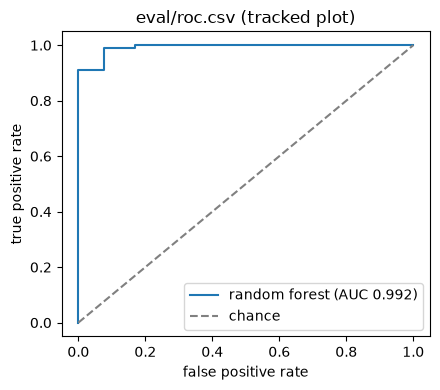

In [25]:
plots_dir = (OUTPUT_DIR / "dvc_plots_section10").resolve()
dvc("plots", "show", "-o", plots_dir, cwd=project)
print("HTML written:", (plots_dir / "index.html").exists())

roc = pd.read_csv(project / "eval" / "roc.csv")
auc = json.loads((project / "eval" / "metrics.json").read_text())["roc_auc"]
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot(roc["fpr"], roc["tpr"], label=f"random forest (AUC {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="chance")
ax.set(xlabel="false positive rate", ylabel="true positive rate", title="eval/roc.csv (tracked plot)")
ax.legend()
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "How do you know a PR didn't make the model worse?" — the pipeline writes metrics files; CI runs `dvc repro` and posts `dvc metrics diff main` (and plots) on the PR, so quality changes are reviewed like code changes.

## 11. Experiments: dvc exp run, show, apply, branch 🔴

Committing every hyperparameter try would clutter Git history. **DVC experiments** run the pipeline with modified params and save each result as a hidden Git reference (under `refs/exps`) instead of a normal commit:

| Command | What it does |
|---|---|
| `dvc exp run -n NAME -S train.max_depth=2` | run the pipeline with a param override (`-S` = `--set-param`), saving the result as an experiment |
| `dvc exp run --queue -S …` then `dvc queue start` | queue many experiments and run them in the background |
| `dvc exp show` | table of experiments: metrics, params, and dependency hashes |
| `dvc exp apply NAME` | copy an experiment's results into the workspace (then `git commit`) |
| `dvc exp branch NAME BRANCH` | turn an experiment into a regular Git branch |
| `dvc exp push origin NAME` | share an experiment through the Git remote (and DVC remote) |

In [26]:
exp_results = {}
for name, overrides in {"deeper": ["train.max_depth=12"], "more-trees": ["train.n_estimators=400"]}.items():
    reset_to_head(project)                                          # every experiment = HEAD + only its own overrides
    args = [arg for override in overrides for arg in ("-S", override)]
    result = dvc("exp", "run", "-n", name, *args, cwd=project, show=False)
    exp_results[name] = result
    print(f"exp {name:10s} {overrides} → {stage_report(result.output)} in {result.seconds:.1f}s")
reset_to_head(project)

dvc("exp", "show", "--md", "--only-changed", "--drop", r"data/.*|src/.*|models/.*", cwd=project)
exps = pd.read_csv(io.StringIO(dvc("exp", "show", "--csv", cwd=project, show=False).stdout))
print(exps[["Experiment", "rev", "typ", "accuracy", "roc_auc", "f1", "train.n_estimators", "train.max_depth"]].to_string(index=False))
print("\nexperiments are Git refs, not commits on main:")
git("show-ref", cwd=project);

exp deeper     ['train.max_depth=12'] → {'ran': ['train', 'evaluate'], 'skipped': ['prepare'], 'from run-cache': []} in 6.0s

exp more-trees ['train.n_estimators=400'] → {'ran': ['train', 'evaluate'], 'skipped': ['prepare'], 'from run-cache': []} in 9.3s

$

dvc exp show --md --only-changed --drop data/.*|src/.*|models/.*

  | Experiment               | Created   | roc_auc   | train.n_estimators   | train.max_depth   |

...

  4406ff971b475089cbbbb4afcc20e7c99381877c refs/exps/exec/EXEC_HEAD

  4406ff971b475089cbbbb4afcc20e7c99381877c refs/heads/main

  32470b727d733e6d73556e0e03fa7c0e400eb94c refs/tags/data-v1

  2cce8ca4ed5bc6a09466f2cc63c61215f7d394c0 refs/tags/data-v2

  4406ff971b475089cbbbb4afcc20e7c99381877c refs/tags/smaller-forest

Notice that `prepare` was skipped in both experiments — they only changed `train.*` params.

⚠️ **Easy trap:** `dvc exp run` leaves each experiment's params and results **in the workspace**. If you launch the next `exp run` straight away, it starts from those modified params and silently *inherits* the previous overrides — your "one change at a time" comparison is confounded. That's why the loop calls `reset_to_head()` (`git checkout HEAD -- .` + `dvc checkout`) before every run. (Queued experiments, `dvc exp run --queue`, each start from the commit instead.)

### ✍️ Your Turn

From the `exps` table, return the **name** (the `Experiment` column) of the experiment with the highest `roc_auc`. Only consider real experiments (rows whose `typ` is not `"baseline"`).

In [27]:
best_exp = None  # TODO: filter out baseline rows, then pick the Experiment with the max roc_auc
real = exps[exps["typ"] != "baseline"]
check("best_exp", best_exp, real.loc[real["roc_auc"].idxmax(), "Experiment"],
      hint="real.loc[real['roc_auc'].idxmax(), 'Experiment'] — or sort_values('roc_auc').")

⏳ best_exp: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
real = exps[exps["typ"] != "baseline"]
best_exp = real.sort_values("roc_auc", ascending=False).iloc[0]["Experiment"]
check("best_exp", best_exp, real.loc[real["roc_auc"].idxmax(), "Experiment"])
```
In a real project, pick on a **validation** metric (as here) and confirm the winner on an untouched test set once.
</details>

Promote the winner: `dvc exp apply` brings its params, metrics, and outputs into the workspace, and a normal `git commit` makes it official. `dvc exp branch` is the alternative when you want a reviewable branch.

In [28]:
real = exps[exps["typ"] != "baseline"]
winner = real.loc[real["roc_auc"].idxmax(), "Experiment"]
head_auc = json.loads(git("show", "HEAD:eval/metrics.json", cwd=project, show=False).stdout)["roc_auc"]
print(f"best experiment: {winner} (ROC AUC {real['roc_auc'].max():.4f}) vs committed HEAD ({head_auc:.4f})")
dvc("exp", "apply", winner, cwd=project)
dvc("params", "diff", cwd=project)
git("add", ".", cwd=project, show=False)
git("commit", "-q", "-m", f"Promote experiment {winner}", cwd=project, show=False)
loser = real.loc[real["roc_auc"].idxmin(), "Experiment"]
dvc("exp", "branch", loser, f"exp-{loser}", cwd=project)
git("branch", "--list", cwd=project);

best experiment: deeper (ROC AUC 0.9944) vs committed HEAD (0.9922)

$

dvc exp apply deeper

  Changes for experiment 'deeper' have been applied to your current workspace.

$

...

  	git checkout exp-more-trees

$

git branch --list

    exp-more-trees

  * main

> 💡 **Interview angle:** "DVC experiments vs MLflow runs?" — DVC experiments are Git-native (code + params + data hashes + metrics, reproducible with `dvc exp apply`), best for pipeline-level iteration in a repo; MLflow shines at logging many runs from anywhere, rich UI, and the model registry. Many teams use both: DVC for data/pipelines, MLflow for tracking and serving.

## 12. DVC in CI 🟡

**CI (continuous integration)** runs checks automatically on every push or pull request. For a DVC project, a typical job: check out code → install → `dvc pull` the data → `dvc repro` → report `dvc metrics diff` against `main`.

A GitHub Actions sketch (store cloud credentials as repository secrets):

```yaml
# .github/workflows/pipeline.yml
name: pipeline
on: [pull_request]
jobs:
  repro:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
        with:
          fetch-depth: 0                  # full history so `dvc metrics diff main` can read main's metrics
      - uses: actions/setup-python@v5
        with:
          python-version: "3.12"
      - run: pip install -r requirements.txt "dvc[s3]"
      - run: dvc pull                     # data + cached outputs (add --run-cache to reuse unchanged stages)
        env:
          AWS_ACCESS_KEY_ID: ${{ secrets.AWS_ACCESS_KEY_ID }}
          AWS_SECRET_ACCESS_KEY: ${{ secrets.AWS_SECRET_ACCESS_KEY }}
      - run: dvc repro
      - run: dvc metrics diff origin/main --md >> "$GITHUB_STEP_SUMMARY"
```

- **CML** (Continuous Machine Learning, from the team that created DVC) adds helpers such as `cml comment create report.md` to post metrics and plots as a PR comment. A plain `gh pr comment --body-file report.md` works too.
- Two cheap **CI gates** that need no training: `dvc status` reports any stage whose code, params, or data changed since `dvc.lock` was written (someone committed without running `dvc repro`), and `dvc repro --dry` prints those stages' commands. A dry run lists only the directly changed stages, not the downstream stages a real run would also rerun.

In [29]:
status = dvc("status", cwd=project)
dry_run = dvc("repro", "--dry", cwd=project)
up_to_date = "up to date" in status.output and not stage_report(dry_run.output)["ran"]
print("CI gate →", "✅ pipeline outputs match the committed code/params/data" if up_to_date else "❌ someone forgot to run dvc repro")

$

dvc status

  Data and pipelines are up to date.

$

dvc repro --dry

...

  Stage 'train' didn't change, skipping

  Stage 'evaluate' didn't change, skipping

  Data and pipelines are up to date.

CI gate →

✅ pipeline outputs match the committed code/params/data

> 💡 **Interview angle:** "How do you put an ML pipeline in CI?" — pull data from the remote with read-only credentials, `dvc repro` (with the run-cache so unchanged stages are free), fail on errors or metric regressions, and post `dvc metrics diff` on the PR. Heavy training runs on self-hosted/GPU runners or is triggered separately.

## 13. DVC vs Git LFS vs MLflow Artifacts vs lakeFS 🟢

| | **DVC** | **Git LFS** | **MLflow artifacts** | **lakeFS** |
|---|---|---|---|---|
| What it is | Git-based data/pipeline versioning CLI | Git extension replacing big files with pointers | files logged per run by a tracking server | Git-like branches/commits over an object store |
| Where bytes live | your remote (S3, GCS, Azure, SSH, folder…) | an LFS server (e.g. GitHub, GitLab) | artifact store (S3, GCS, local…) | your object store, managed by a lakeFS server |
| Versioning unit | file/folder hash, pinned by a Git commit | file, pinned by a Git commit | per run | commit of a whole repository/bucket |
| Pipelines & caching | ✅ `dvc.yaml`, `dvc repro`, run-cache | ❌ | ❌ (tracking only) | ❌ (pairs with Airflow/Spark etc.) |
| Experiments/metrics | ✅ `dvc exp`, `metrics diff` | ❌ | ✅ rich UI, model registry | ❌ |
| Infra needed | none beyond storage | LFS-enabled Git host | tracking server for teams | a lakeFS server |
| Sweet spot | ML repos: data + models + reproducible pipelines | a few large binaries in a code repo | experiment tracking, model registry, serving | data lakes: TB–PB, many consumers, atomic data releases |

Rules of thumb:
- **A handful of large assets in an app repo** (game textures, a demo model) → Git LFS.
- **An ML project whose data, code, and models must reproduce together** → DVC (often with MLflow for tracking/registry).
- **A company data lake with Spark/Trino consumers** → lakeFS or table formats with time travel (Delta Lake, Apache Iceberg).

Fun fact from `dvc init`'s own output above: DVC's GitHub home is now `treeverse/dvc` — Treeverse is the company behind lakeFS, which took over DVC's stewardship.

> 💡 **Interview angle:** "Why not Git LFS?" — LFS versions files but has no pipelines, no stage caching, no params/metrics comparison, and pulls blobs through the Git host; DVC keeps data in your own bucket and understands ML workflows.

## 🔧 Build It From Scratch

The core of DVC is a **content-addressable cache**: store each file under its hash, restore by hash, and describe folders with a sorted listing. Let's build one in ~40 lines and prove it produces **exactly** the hashes and cache paths DVC wrote for the same files.

In [30]:
class TinyCache:
    """A minimal content-addressable file store with DVC's layout: <root>/files/md5/<2 chars>/<30 chars>."""

    def __init__(self, root):
        self.root = Path(root)

    @staticmethod
    def md5_file(path, chunk_size=1 << 20):
        h = hashlib.md5()
        with open(path, "rb") as f:
            for block in iter(lambda: f.read(chunk_size), b""):   # streaming: works for files bigger than RAM
                h.update(block)
        return h.hexdigest()

    def object_path(self, md5):
        return self.root / "files" / "md5" / md5[:2] / md5[2:]

    def add(self, path):
        md5 = self.md5_file(path)
        target = self.object_path(md5)
        if not target.exists():                                   # deduplication: identical content stored once
            target.parent.mkdir(parents=True, exist_ok=True)
            shutil.copyfile(path, target)
        return md5

    def add_dir(self, folder):
        folder = Path(folder)
        entries = sorted(({"md5": self.add(p), "relpath": p.relative_to(folder).as_posix()}
                          for p in folder.rglob("*") if p.is_file()), key=lambda e: e["relpath"])
        listing = json.dumps(entries, sort_keys=True).encode("utf-8")
        md5 = hashlib.md5(listing).hexdigest() + ".dir"
        target = self.object_path(md5)
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_bytes(listing)
        return md5

    def checkout(self, md5, dest):
        dest = Path(dest)
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(self.object_path(md5), dest)
        assert self.md5_file(dest) == md5, "cache object is corrupted"
        return dest


tiny = TinyCache(WORK / "tiny-cache")

# 1) a single file: same hash and same cache path as DVC
file_md5 = tiny.add(project / "data" / "breast_cancer.csv")
dvc_file_md5 = yaml.safe_load((project / "data" / "breast_cancer.csv.dvc").read_text())["outs"][0]["md5"]
assert file_md5 == dvc_file_md5
assert tiny.object_path(file_md5).relative_to(tiny.root) == (project / ".dvc" / "cache" / "files" / "md5" / dvc_file_md5[:2] / dvc_file_md5[2:]).relative_to(project / ".dvc" / "cache")
print("file hash matches DVC ✅", file_md5)

# 2) a folder: same .dir hash as DVC
folder_md5 = tiny.add_dir(deliveries)
dvc_dir_md5 = yaml.safe_load((project / "data" / "deliveries.dvc").read_text())["outs"][0]["md5"]
assert folder_md5 == dvc_dir_md5
print("folder hash matches DVC ✅", folder_md5)

# 3) dedup + restore by hash
n_objects = len([p for p in tiny.root.rglob("*") if p.is_file()])
tiny.add(project / "data" / "breast_cancer.csv")                  # adding the same content again stores nothing new
restored = tiny.checkout(file_md5, WORK / "restored" / "patients.csv")
print("restored file rows:", len(pd.read_csv(restored)), "| identical bytes:", restored.read_bytes() == (project / "data" / "breast_cancer.csv").read_bytes())
assert len([p for p in tiny.root.rglob("*") if p.is_file()]) == n_objects, "re-adding identical content must not create objects"
print("objects in tiny cache:", sorted(p.relative_to(tiny.root).as_posix()[:22] + "…" for p in tiny.root.rglob("*") if p.is_file()))

file hash matches DVC ✅

5afc23b9622f8f9ffa60824f4e97d0d5

folder hash matches DVC ✅

71232168f86d804e4fb5b652ebe1c52a.dir

restored file rows:

569

| identical bytes:

True

objects in tiny cache:

['files/md5/31/b274700f4…', 'files/md5/58/8b4ab1fbe…', 'files/md5/5a/fc23b9622…', 'files/md5/71/232168f86…', 'files/md5/c3/efd18e80f…']

What real DVC adds on top: reflinks/hardlinks instead of copies, a hash database so unchanged files aren't re-hashed, remotes, parallel transfers, garbage collection (`dvc gc`), and the pipeline engine.

## ⚠️ Common Pitfalls

Each pitfall runs in its own small repo, `pitfalls`, with the real **wine** dataset.

In [31]:
pit = new_repo(WORK / "pitfalls")
pit_remote = WORK / "pitfalls-remote"
pit_remote.mkdir()
dvc("remote", "add", "-d", "storage", pit_remote, cwd=pit, show=False)
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True).frame                              # 178 real wines
(pit / "data").mkdir()
wine.iloc[:100].to_csv(pit / "data" / "wine.csv", index=False)
dvc("add", "data/wine.csv", cwd=pit, show=False)
git("add", ".", cwd=pit, show=False)
git("commit", "-q", "-m", "wine v1 (100 rows)", cwd=pit, show=False)
dvc("push", cwd=pit, show=False)
wine.to_csv(pit / "data" / "wine.csv", index=False)
dvc("add", "data/wine.csv", cwd=pit, show=False)
git("add", ".", cwd=pit, show=False)
git("commit", "-q", "-m", "wine v2 (178 rows)", cwd=pit, show=False)
dvc("push", cwd=pit, show=False)
print("pitfalls repo ready:", git("log", "--oneline", cwd=pit, show=False).stdout.strip().replace("\n", " | "))

pitfalls repo ready:

59b82a2 wine v2 (178 rows) | b79fc74 wine v1 (100 rows)

### ❌ Pitfall 1 — `git checkout` without `dvc checkout`

Git switches the *pointer*, but the data in your workspace stays the same until DVC updates it.

In [32]:
git("checkout", "HEAD~1", "--", "data/wine.csv.dvc", cwd=pit, show=False)
print("❌ .dvc file says v1 (100 rows), workspace file still has", len(pd.read_csv(pit / "data" / "wine.csv")), "rows")
dvc("status", cwd=pit)
dvc("checkout", cwd=pit, show=False)
print("✅ after dvc checkout:", len(pd.read_csv(pit / "data" / "wine.csv")), "rows")
git("checkout", "HEAD", "--", "data/wine.csv.dvc", cwd=pit, show=False)
dvc("checkout", cwd=pit, show=False)
print("   (tip: `dvc install` adds a Git post-checkout hook that runs dvc checkout for you)")

❌ .dvc file says v1 (100 rows), workspace file still has

178

rows

$

dvc status

...

  		modified:           data/wine.csv

✅ after dvc checkout:

100

rows

   (tip: `dvc install` adds a Git post-checkout hook that runs dvc checkout for you)

### ❌ Pitfall 2 — Forgetting to declare the script as a dependency

If the code isn't in `deps`, changing it doesn't invalidate the stage, and DVC happily reports "up to date" with stale results.

In [33]:
write(pit / "report.py", """
    import json
    import pandas as pd
    df = pd.read_csv("data/wine.csv")
    json.dump({"mean_alcohol": round(df["alcohol"].mean(), 3)}, open("report.json", "w"))
""")
dvc("stage", "add", "-n", "report", "-d", "data/wine.csv", "-M", "report.json", "python report.py", cwd=pit, show=False)
dvc("repro", cwd=pit, show=False)
(pit / "report.py").write_text((pit / "report.py").read_text().replace('"mean_alcohol": round(df["alcohol"].mean(), 3)',
                                                                        '"median_alcohol": round(df["alcohol"].median(), 3)'))
stale = dvc("repro", cwd=pit)
print("❌ script changed, but report.json still says:", (pit / "report.json").read_text())

dvc("stage", "add", "-f", "-n", "report", "-d", "data/wine.csv", "-d", "report.py", "-M", "report.json", "python report.py", cwd=pit, show=False)
fixed = dvc("repro", cwd=pit, show=False)
print("✅ with report.py in deps, the stage reran:", stage_report(fixed.output)["ran"], "→", (pit / "report.json").read_text())

$

dvc repro

  'data/wine.csv.dvc' didn't change, skipping

  Stage 'report' didn't change, skipping

  Data and pipelines are up to date.

...

{"mean_alcohol": 13.001}

✅ with report.py in deps, the stage reran:

['report']

→

{"median_alcohol": 13.05}

### ❌ Pitfall 3 — Committing and forgetting `dvc push`

Git has the new pointer, the remote doesn't have the bytes. Your teammate's `dvc pull` fails.

In [34]:
wine.sample(frac=1.0, random_state=1).to_csv(pit / "data" / "wine.csv", index=False)     # a reshuffled "v3"
dvc("add", "data/wine.csv", cwd=pit, show=False)
git("add", ".", cwd=pit, show=False)
git("commit", "-q", "-m", "wine v3 — forgot to push", cwd=pit, show=False)
colleague = WORK / "pit-colleague"
git("clone", "-q", pit, colleague, cwd=WORK, show=False)
bad_pull = dvc("pull", cwd=colleague, check=False, max_lines=8)
print("❌ colleague's pull failed:", bad_pull.returncode != 0)

dvc("push", cwd=pit)
good_pull = dvc("pull", cwd=colleague, check=False, show=False)
print("✅ after pushing, colleague's pull succeeded:", good_pull.returncode == 0)

$

dvc pull

  Everything is up to date.

  md5: 810352527e0c9a35f8af0a76f4803a88

  ERROR: failed to pull data from the cloud - Checkout failed for following targets:

...

$

dvc push

  1 file pushed

✅ after pushing, colleague's pull succeeded:

True

### ❌ Pitfall 4 — `git add`-ing the data before `dvc add`

Once Git tracks a file, DVC refuses to take it over (and the bytes are already in Git history).

In [35]:
wine.head(20).to_csv(pit / "data" / "wine_sample.csv", index=False)
git("add", "data/wine_sample.csv", cwd=pit, show=False)
refused = dvc("add", "data/wine_sample.csv", cwd=pit, check=False)
print("❌ dvc add refused:", refused.returncode != 0)

git("rm", "-q", "--cached", "data/wine_sample.csv", cwd=pit)          # untrack in Git, keep the file
accepted = dvc("add", "data/wine_sample.csv", cwd=pit, show=False)
print("✅ after `git rm --cached`, dvc add worked:", (pit / "data" / "wine_sample.csv.dvc").exists())
print("   (if it was already committed, the old bytes stay in Git history — rewriting history is the only cure)")

$

dvc add data/wine_sample.csv

  ERROR:  output 'data/wine_sample.csv' is already tracked by SCM (e.g. Git).

      You can remove it from Git, then add to DVC.

          To stop tracking from Git:

...

$

git rm -q --cached data/wine_sample.csv

✅ after `git rm --cached`, dvc add worked:

True

   (if it was already committed, the old bytes stay in Git history — rewriting history is the only cure)

### ❌ Pitfall 5 — Non-deterministic stages

A stage without a fixed random seed produces different outputs every run, so "reproducible" pipelines aren't, and caches/metrics diffs become noise.

In [36]:
write(pit / "split.py", """
    import sys
    import pandas as pd
    seed = None if sys.argv[1] == "none" else int(sys.argv[1])
    pd.read_csv("data/wine.csv").sample(frac=0.8, random_state=seed).to_csv("train_split.csv", index=False)
""")


def split_hashes(seed_arg, runs=2):
    hashes = []
    for _ in range(runs):
        run([sys.executable, "split.py", seed_arg], cwd=pit, show=False)
        hashes.append(hashlib.md5((pit / "train_split.csv").read_bytes()).hexdigest()[:10])
    return hashes


print("❌ no seed  :", split_hashes("none"), "→ identical?", len(set(split_hashes("none"))) == 1)
print("✅ seed = 42:", split_hashes("42"), "→ identical?", len(set(split_hashes("42"))) == 1)

❌ no seed  :

['cf96456827', 'bf9870c382']

→ identical?

False

✅ seed = 42:

['a44123df55', 'a44123df55']

→ identical?

True

## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Read a `.dvc` file
Write `parse_dvc_file(path)` that returns `{"md5": ..., "size": ..., "path": ...}` for the (single) output in a `.dvc` file.

In [37]:
def parse_dvc_file(path):
    return None  # TODO


data_file = project / "data" / "breast_cancer.csv"
got = parse_dvc_file(project / "data" / "breast_cancer.csv.dvc")
check("parse_dvc_file", got,
      {"md5": hashlib.md5(data_file.read_bytes()).hexdigest(), "size": data_file.stat().st_size, "path": "breast_cancer.csv"},
      hint="yaml.safe_load(Path(path).read_text())['outs'][0] has the keys you need.")

⏳ parse_dvc_file: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
def parse_dvc_file(path):
    out = yaml.safe_load(Path(path).read_text())["outs"][0]
    return {"md5": out["md5"], "size": out["size"], "path": out["path"]}


data_file = project / "data" / "breast_cancer.csv"
got = parse_dvc_file(project / "data" / "breast_cancer.csv.dvc")
check("parse_dvc_file", got,
      {"md5": hashlib.md5(data_file.read_bytes()).hexdigest(), "size": data_file.stat().st_size, "path": "breast_cancer.csv"})
```
Note `path` is relative to the `.dvc` file's folder, not the repo root.
</details>

### 🟢 Exercise 2 — Where is it in the cache?
Write `cache_relpath(md5)` returning the path (as a string, relative to the repo root) where DVC 3 stores a file with that hash.

In [38]:
def cache_relpath(md5):
    return None  # TODO: ".dvc/cache/files/md5/<first 2>/<rest>"


md5_now = yaml.safe_load((project / "data" / "breast_cancer.csv.dvc").read_text())["outs"][0]["md5"]
got = cache_relpath(md5_now)
check("cache_relpath", None if got is None else [got, (project / got).is_file()],
      [f".dvc/cache/files/md5/{md5_now[:2]}/{md5_now[2:]}", True], hint="Slice the hash: md5[:2] and md5[2:].")

⏳ cache_relpath: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
def cache_relpath(md5):
    return f".dvc/cache/files/md5/{md5[:2]}/{md5[2:]}"


md5_now = yaml.safe_load((project / "data" / "breast_cancer.csv.dvc").read_text())["outs"][0]["md5"]
got = cache_relpath(md5_now)
check("cache_relpath", [got, (project / got).is_file()], [f".dvc/cache/files/md5/{md5_now[:2]}/{md5_now[2:]}", True])
```
The 2-character subfolder keeps any single directory from holding millions of files.
</details>

### 🟢 Exercise 3 — Which remote is the default?
Ask DVC (use the `dvc()` helper with `cwd=project, show=False`) which remote is the **default** for `project`, and return its name as a clean string.

In [39]:
default_remote = None  # TODO: run a dvc command and take its .stdout
check("default_remote", default_remote, "storage", hint="`dvc remote default` with no name prints the current default; .strip() the newline.")

⏳ default_remote: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
default_remote = dvc("remote", "default", cwd=project, show=False).stdout.strip()
check("default_remote", default_remote, "storage")
```
Why not parse `dvc remote list`? When its output is captured (not a terminal), DVC wraps long URLs at 80 columns, so the name and the `(default)` marker can land on different lines — prefer commands that print exactly the value you need. The same setting is stored in `.dvc/config` under `[core] remote = storage`, and `dvc config core.remote` prints it too.
</details>

### 🟡 Exercise 4 — Write a stage definition
Build the Python dict for a `featurize` stage (as it would appear under `stages:` in `dvc.yaml`) that runs `python src/featurize.py`, depends on `src/featurize.py` and `data/prepared`, reads the whole `featurize` params section, and outputs `data/features`. Use the key order `cmd, deps, params, outs`.

In [40]:
featurize_stage = None  # TODO
check("featurize_stage", featurize_stage,
      {"cmd": "python src/featurize.py", "deps": ["src/featurize.py", "data/prepared"], "params": ["featurize"], "outs": ["data/features"]},
      hint="Every field except cmd is a list of strings.")

⏳ featurize_stage: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
featurize_stage = {
    "cmd": "python src/featurize.py",
    "deps": ["src/featurize.py", "data/prepared"],
    "params": ["featurize"],
    "outs": ["data/features"],
}
check("featurize_stage", featurize_stage,
      {"cmd": "python src/featurize.py", "deps": ["src/featurize.py", "data/prepared"], "params": ["featurize"], "outs": ["data/features"]})
print(yaml.safe_dump({"stages": {"featurize": featurize_stage}}, sort_keys=False))
```
</details>

### 🟡 Exercise 5 — Re-implement `dvc params diff --json`
In section 9 we saved DVC's real output in `PARAMS_DIFF_JSON` and the old params in `params_before`. Write `params_diff(old, new)` that flattens nested dicts into dotted keys (`train.n_estimators`) and returns `{"params.yaml": {key: {"old": ..., "new": ..., "diff": new - old}}}` for **changed** keys only.

In [41]:
def params_diff(old, new):
    return None  # TODO


params_after = yaml.safe_load(git("show", "smaller-forest:params.yaml", cwd=project, show=False).stdout)   # the commit "Smaller forest"
check("params_diff", params_diff(params_before, params_after), PARAMS_DIFF_JSON,
      hint="Write a recursive flatten(d, prefix='') first, then compare the two flat dicts.")

⏳ params_diff: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
def params_diff(old, new):
    def flatten(d, prefix=""):
        flat = {}
        for key, value in d.items():
            name = f"{prefix}{key}"
            if isinstance(value, dict):
                flat.update(flatten(value, name + "."))
            else:
                flat[name] = value
        return flat

    a, b = flatten(old), flatten(new)
    changed = {k: {"old": a.get(k), "new": b.get(k), "diff": b[k] - a[k]} for k in sorted(a.keys() | b.keys()) if a.get(k) != b.get(k)}
    return {"params.yaml": changed}


params_after = yaml.safe_load(git("show", "smaller-forest:params.yaml", cwd=project, show=False).stdout)
check("params_diff", params_diff(params_before, params_after), PARAMS_DIFF_JSON)
```
Real DVC also handles added/removed keys and non-numeric values (no `diff` field).
</details>

### 🔴 Exercise 6 — Which stages must rerun? (interview-style)
Given a pipeline (each stage's `deps` and `outs`) and a set of changed paths, return the stages that must rerun **in pipeline order**. A stage reruns if any dep changed *or* any dep is an output of a stage that reruns. Assume stages are listed in a valid run order.

In [42]:
PIPELINE = {
    "prepare":   {"deps": ["data/raw", "src/prepare.py"], "outs": ["data/prepared"]},
    "featurize": {"deps": ["data/prepared", "src/featurize.py"], "outs": ["data/features"]},
    "train":     {"deps": ["data/features", "src/train.py", "params:train"], "outs": ["models/model.pkl"]},
    "evaluate":  {"deps": ["models/model.pkl", "data/features", "src/evaluate.py"], "outs": ["eval/metrics.json"]},
    "docs":      {"deps": ["README.md"], "outs": ["site"]},
}

In [43]:
def stages_to_rerun(pipeline, changed):
    return None  # TODO


got = stages_to_rerun(PIPELINE, {"params:train"})
got2 = None if got is None else stages_to_rerun(PIPELINE, {"src/featurize.py", "README.md"})
check("stages_to_rerun", None if got is None else [got, got2, stages_to_rerun(PIPELINE, set())],
      [["train", "evaluate"], ["featurize", "train", "evaluate", "docs"], []],
      hint="Walk stages in order; keep a set of 'dirty' paths that starts as `changed` and grows with the outs of every stage you mark.")

⏳ stages_to_rerun: not attempted yet — replace None with your answer.

<details><summary>💡 Show solution</summary>

```python
def stages_to_rerun(pipeline, changed):
    dirty = set(changed)
    rerun = []
    for name, stage in pipeline.items():          # dict order = run order
        if dirty & set(stage["deps"]):
            rerun.append(name)
            dirty |= set(stage["outs"])           # its outputs will change → downstream becomes dirty
    return rerun


got = stages_to_rerun(PIPELINE, {"params:train"})
got2 = stages_to_rerun(PIPELINE, {"src/featurize.py", "README.md"})
check("stages_to_rerun", [got, got2, stages_to_rerun(PIPELINE, set())],
      [["train", "evaluate"], ["featurize", "train", "evaluate", "docs"], []])
```
Follow-ups interviewers ask: *"What if stages aren't given in order?"* → topologically sort first (Kahn's algorithm) and detect cycles. *"What if a dep is a folder and a file inside it changed?"* → treat path prefixes as matches, which is what DVC's folder hashes achieve.
</details>

## 🚀 Mini Project: A Versioned 4-Stage House Price Pipeline

**Goal:** build a real **prepare → featurize → train → evaluate** pipeline on the California housing data in its own Git + DVC repo, then live through two everyday events — **new data arrives** and **we tune parameters** — and let DVC tell us what reran and whether the model got better.

**Rules we follow (no leakage):** a **fixed test holdout** is set aside before anything else and is touched once at the very end; all comparisons and the choice of the best experiment use a **validation** split. The validation split is assigned by a **stable hash of each row's id**, so a district that is in validation stays in validation when the dataset grows.

### Step 1 — Create the raw data versions

In [44]:
from sklearn.model_selection import train_test_split

FEATURES = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
raw = housing.reset_index(names="row_id")                              # a stable id per district
pool, holdout = train_test_split(raw, test_size=0.2, random_state=7)   # holdout = final test set, fixed forever
pool = pool.sort_values("row_id")
first_delivery = pool.sample(frac=0.4, random_state=7).sort_values("row_id")   # v1: the data we had at first

house = new_repo(WORK / "house-prices")
house_remote = WORK / "house-remote"
house_remote.mkdir()
dvc("remote", "add", "-d", "storage", house_remote, cwd=house, show=False)
(house / "data" / "raw").mkdir(parents=True)
first_delivery.to_csv(house / "data" / "raw" / "pool.csv", index=False)
holdout.to_csv(house / "data" / "raw" / "holdout.csv", index=False)
print(f"v1 pool: {len(first_delivery):,} rows | full pool (v2): {len(pool):,} rows | fixed holdout: {len(holdout):,} rows")

v1 pool: 6,605 rows | full pool (v2): 16,512 rows | fixed holdout: 4,128 rows

### Step 2 — Write the four stages, `params.yaml`, and `dvc.yaml`

In [45]:
write(house / "params.yaml", """
    prepare:
      max_ave_occup: 20        # drop implausible districts (> 20 people per household) from TRAINING data only
      val_percent: 20          # % of pool rows (by stable hash) used for validation
    featurize:
      n_geo_clusters: 8        # KMeans clusters on latitude/longitude (0 = no geo features)
    train:
      learning_rate: 0.1
      max_iter: 200
      max_leaf_nodes: 31
      seed: 0
""")

write(house / "src" / "prepare.py", """
    import zlib
    from pathlib import Path

    import pandas as pd
    import yaml

    params = yaml.safe_load(Path("params.yaml").read_text())["prepare"]
    pool = pd.read_csv("data/raw/pool.csv")
    holdout = pd.read_csv("data/raw/holdout.csv")
    required = {"row_id", "MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude", "MedHouseVal"}
    for name, df in [("pool", pool), ("holdout", holdout)]:
        missing = required - set(df.columns)
        if missing:
            raise SystemExit(f"{name} is missing columns: {sorted(missing)}")

    n_raw = len(pool)
    pool = pool.drop_duplicates(subset="row_id")
    pool = pool[pool["AveOccup"] <= params["max_ave_occup"]]
    bucket = pool["row_id"].map(lambda i: zlib.crc32(str(i).encode()) % 100)   # stable: same id → same bucket forever
    is_val = bucket < params["val_percent"]

    out = Path("data/prepared")
    out.mkdir(parents=True, exist_ok=True)
    pool[~is_val].to_csv(out / "train.csv", index=False)
    pool[is_val].to_csv(out / "val.csv", index=False)
    holdout.to_csv(out / "test.csv", index=False)
    print(f"pool {n_raw} → kept {len(pool)} | train {int((~is_val).sum())} | val {int(is_val.sum())} | test {len(holdout)}")
""")

write(house / "src" / "featurize.py", """
    import pickle
    from pathlib import Path

    import numpy as np
    import pandas as pd
    import yaml
    from sklearn.cluster import KMeans

    params = yaml.safe_load(Path("params.yaml").read_text())["featurize"]
    splits = {name: pd.read_csv(f"data/prepared/{name}.csv") for name in ("train", "val", "test")}
    k = params["n_geo_clusters"]
    kmeans = KMeans(n_clusters=k, n_init=5, random_state=0).fit(splits["train"][["Latitude", "Longitude"]]) if k > 0 else None


    def featurize(df):
        extra = {
            "bedrooms_per_room": df["AveBedrms"] / df["AveRooms"],
            "log_population": np.log1p(df["Population"]),
        }
        if kmeans is not None:                          # fitted on TRAIN only
            distances = kmeans.transform(df[["Latitude", "Longitude"]])
            extra.update({f"geo_dist_{j}": distances[:, j] for j in range(k)})
        return pd.concat([df, pd.DataFrame(extra, index=df.index)], axis=1)


    out = Path("data/features")
    out.mkdir(parents=True, exist_ok=True)
    for name, df in splits.items():
        featurize(df).to_csv(out / f"{name}.csv", index=False)
    print(f"features: {featurize(splits['val']).shape[1] - 2} columns (k={k})")
""")

write(house / "src" / "train.py", """
    import pickle
    import time
    from pathlib import Path

    import pandas as pd
    import yaml
    from sklearn.ensemble import HistGradientBoostingRegressor

    params = yaml.safe_load(Path("params.yaml").read_text())["train"]
    train = pd.read_csv("data/features/train.csv")
    X, y = train.drop(columns=["row_id", "MedHouseVal"]), train["MedHouseVal"]
    start = time.perf_counter()
    model = HistGradientBoostingRegressor(learning_rate=params["learning_rate"], max_iter=params["max_iter"],
                                          max_leaf_nodes=params["max_leaf_nodes"], early_stopping=False,
                                          random_state=params["seed"]).fit(X, y)
    Path("models").mkdir(exist_ok=True)
    Path("models/model.pkl").write_bytes(pickle.dumps(model))
    print(f"trained on {len(train)} rows in {time.perf_counter() - start:.1f}s")
""")

write(house / "src" / "evaluate.py", """
    import json
    import pickle
    from pathlib import Path

    import numpy as np
    import pandas as pd
    from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

    model = pickle.loads(Path("models/model.pkl").read_bytes())
    val = pd.read_csv("data/features/val.csv")
    X, y = val.drop(columns=["row_id", "MedHouseVal"]), val["MedHouseVal"]
    pred = model.predict(X)
    metrics = {
        "val_rmse": round(float(root_mean_squared_error(y, pred)), 4),
        "val_mae": round(float(mean_absolute_error(y, pred)), 4),
        "val_r2": round(float(r2_score(y, pred)), 4),
        "n_train": int(len(pd.read_csv("data/features/train.csv"))),
    }
    Path("eval").mkdir(exist_ok=True)
    Path("eval/metrics.json").write_text(json.dumps(metrics, indent=2))
    pd.DataFrame({"actual": y, "predicted": np.round(pred, 4)}).to_csv("eval/val_predictions.csv", index=False)
    print(metrics)
""")

write(house / "dvc.yaml", """
    stages:
      prepare:
        cmd: python src/prepare.py
        deps: [src/prepare.py, data/raw]
        params: [prepare]
        outs: [data/prepared]
      featurize:
        cmd: python src/featurize.py
        deps: [src/featurize.py, data/prepared]
        params: [featurize]
        outs: [data/features]
      train:
        cmd: python src/train.py
        deps: [src/train.py, data/features/train.csv]
        params: [train]
        outs: [models/model.pkl]
      evaluate:
        cmd: python src/evaluate.py
        deps: [src/evaluate.py, models/model.pkl, data/features/val.csv]
        metrics:
          - eval/metrics.json:
              cache: false
        plots:
          - eval/val_predictions.csv:
              template: scatter
              x: actual
              y: predicted
              cache: false
""")
dvc("add", "data/raw", cwd=house)
dvc("dag", cwd=house);

$

dvc add data/raw

  To track the changes with git, run:

  	git add data/raw.dvc data/.gitignore

  To enable auto staging, run:

...

             **    **       

               *  *         

          +----------+      

          | evaluate |      

          +----------+

### Step 3 — Run v1 and commit it

In [46]:
v1_run = dvc("repro", cwd=house, max_lines=40)
print(f"\n⏱️ {v1_run.seconds:.1f}s → {stage_report(v1_run.output)}")
git("add", ".", cwd=house, show=False)
git("commit", "-q", "-m", "Pipeline on first data delivery", cwd=house, show=False)
git("tag", "v1", cwd=house, show=False)
dvc("push", cwd=house)
v1_metrics = json.loads((house / "eval" / "metrics.json").read_text())
print("v1 metrics:", v1_metrics)

$

dvc repro

  'data/raw.dvc' didn't change, skipping

  Running stage 'prepare':

  > python src/prepare.py

...

$

dvc push

  12 files pushed

v1 metrics:

{'val_rmse': 0.4543, 'val_mae': 0.3042, 'val_r2': 0.8479, 'n_train': 5303}

### Step 4 — New data arrives: update the raw data and reproduce

In [47]:
pool.to_csv(house / "data" / "raw" / "pool.csv", index=False)       # the full pool: 2.5× more labelled districts
dvc("status", cwd=house)
dvc("add", "data/raw", cwd=house, show=False)
v2_run = dvc("repro", cwd=house)
v2_report = stage_report(v2_run.output)
print(f"\n⏱️ {v2_run.seconds:.1f}s → {v2_report}")
assert v2_report["ran"] == ["prepare", "featurize", "train", "evaluate"], "new raw data must invalidate every stage"
git("add", ".", cwd=house, show=False)
git("commit", "-q", "-m", "Retrain on full data delivery", cwd=house, show=False)
git("tag", "v2", cwd=house, show=False)
dvc("push", cwd=house, show=False)

dvc("metrics", "diff", "v1", "v2", cwd=house)
data_diff = json.loads(dvc("metrics", "diff", "v1", "v2", "--json", cwd=house, show=False).stdout)["eval/metrics.json"]
rmse_change = data_diff["val_rmse"]["diff"] / data_diff["val_rmse"]["old"]
print(f"More data: n_train {data_diff['n_train']['old']} → {data_diff['n_train']['new']}, "
      f"validation RMSE {'improved' if rmse_change < 0 else 'got worse'} by {abs(rmse_change):.1%}")

$

dvc status

  prepare:

  	changed deps:

  		modified:           data/raw

...

  eval/metrics.json  n_train   5303    13184   7881

  eval/metrics.json  val_mae   0.3042  0.2854  -0.0188

  eval/metrics.json  val_r2    0.8479  0.8561  0.0082

  eval/metrics.json  val_rmse  0.4543  0.4399  -0.0144

More data: n_train 5303 → 13184, validation RMSE improved by 3.2%

### Step 5 — Tune parameters with experiments

Three ideas, each changing a different part of the pipeline. Watch which stages DVC reruns.

In [48]:
experiments = {
    "slow-lr":    ["train.learning_rate=0.05", "train.max_iter=300"],
    "big-leaves": ["train.max_leaf_nodes=63"],
    "no-geo":     ["featurize.n_geo_clusters=0"],
    "more-geo":   ["featurize.n_geo_clusters=16"],
}
exp_stage_runs = {}
for name, overrides in experiments.items():
    reset_to_head(house)                                            # start each experiment from the committed v2
    args = [arg for override in overrides for arg in ("-S", override)]
    result = dvc("exp", "run", "-n", name, *args, cwd=house, show=False)
    exp_stage_runs[name] = stage_report(result.output)["ran"]
    print(f"{name:10s} {str(overrides):52s} ran {exp_stage_runs[name]} in {result.seconds:.1f}s")
reset_to_head(house)

assert "prepare" not in sum(exp_stage_runs.values(), []), "no experiment changed prepare's inputs"
assert "featurize" not in exp_stage_runs["slow-lr"] and "featurize" in exp_stage_runs["no-geo"]

# prove the experiments are independent: each differs from the baseline only in its own overrides
check_table = pd.read_csv(io.StringIO(dvc("exp", "show", "--csv", cwd=house, show=False).stdout))
baseline_row = check_table[(check_table["typ"] == "baseline") & (check_table["rev"] != "workspace")].iloc[0]
param_cols = [c for c in check_table.columns if c.startswith(("prepare.", "featurize.", "train."))]
for name, overrides in experiments.items():
    row = check_table[check_table["Experiment"] == name].iloc[0]
    changed = sorted(c for c in param_cols if float(row[c]) != float(baseline_row[c]))
    assert changed == sorted(o.split("=")[0] for o in overrides), (name, changed)
print("✅ every experiment changed only its own parameters")

slow-lr    ['train.learning_rate=0.05', 'train.max_iter=300']   ran ['train', 'evaluate'] in 5.6s

big-leaves ['train.max_leaf_nodes=63']                          ran ['train', 'evaluate'] in 5.3s

no-geo     ['featurize.n_geo_clusters=0']                       ran ['featurize', 'train', 'evaluate'] in 4.7s

more-geo   ['featurize.n_geo_clusters=16']                      ran ['featurize', 'train', 'evaluate'] in 4.6s

✅ every experiment changed only its own parameters

### Step 6 — Compare everything and promote the best on **validation**

     label           typ  val_rmse  val_mae  val_r2  featurize.n_geo_clusters  train.learning_rate  train.max_iter  train.max_leaf_nodes
big-leaves branch_commit    0.4372   0.2808  0.8579                         8                 0.10             200                    63
  more-geo branch_commit    0.4388   0.2820  0.8568                        16                 0.10             200                    31
      main      baseline    0.4399   0.2854  0.8561                         8                 0.10             200                    31
   slow-lr   branch_base    0.4426   0.2868  0.8543                         8                 0.05             300                    31
    no-geo branch_commit    0.4533   0.2961  0.8472                         0                 0.10             200                    31


best on validation: big-leaves (RMSE 0.4372) vs committed v2 (0.4399)

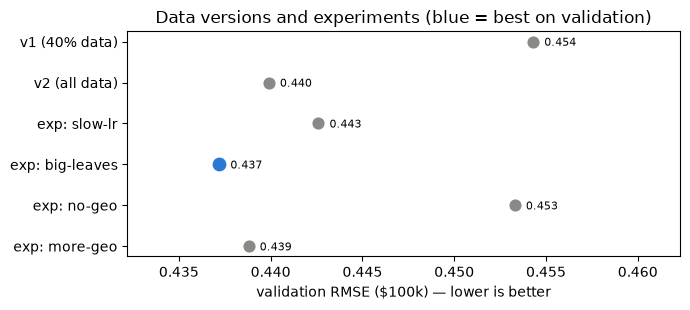

In [49]:
table = pd.read_csv(io.StringIO(dvc("exp", "show", "--csv", cwd=house, show=False).stdout))
table["label"] = table["Experiment"].fillna(table["rev"])
cols = ["label", "typ", "val_rmse", "val_mae", "val_r2", "featurize.n_geo_clusters",
        "train.learning_rate", "train.max_iter", "train.max_leaf_nodes"]
comparison = table[table["rev"] != "workspace"][cols].sort_values("val_rmse")
print(comparison.to_string(index=False))

best = comparison.iloc[0]
baseline_rmse = float(table.loc[table["typ"] == "baseline", "val_rmse"].iloc[-1])
print(f"\nbest on validation: {best['label']} (RMSE {best['val_rmse']:.4f}) vs committed v2 ({baseline_rmse:.4f})")

history = pd.DataFrame(
    [{"run": "v1 (40% data)", "val_rmse": data_diff["val_rmse"]["old"]}, {"run": "v2 (all data)", "val_rmse": data_diff["val_rmse"]["new"]}]
    + [{"run": f"exp: {n}", "val_rmse": float(table.loc[table["Experiment"] == n, "val_rmse"].iloc[0])} for n in experiments]
)
fig, ax = plt.subplots(figsize=(7, 3.2))
positions = np.arange(len(history))
is_best = (history["val_rmse"] == history["val_rmse"].min()).to_numpy()
ax.scatter(history["val_rmse"][~is_best], positions[~is_best], s=60, color="#8a8985", zorder=3)
ax.scatter(history["val_rmse"][is_best], positions[is_best], s=80, color="#2a78d6", zorder=3)
for pos, value in zip(positions, history["val_rmse"]):
    ax.annotate(f"{value:.3f}", (value, pos), xytext=(8, -3), textcoords="offset points", fontsize=8)
ax.set_yticks(positions, history["run"])
ax.set_xlim(history["val_rmse"].min() - 0.005, history["val_rmse"].max() + 0.008)
ax.grid(axis="y", visible=False)
ax.set(xlabel="validation RMSE ($100k) — lower is better", title="Data versions and experiments (blue = best on validation)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
if best["typ"] != "baseline":
    dvc("exp", "apply", best["label"], cwd=house)
    git("add", ".", cwd=house, show=False)
    git("commit", "-q", "-m", f"Promote experiment {best['label']}", cwd=house, show=False)
    print(f"promoted {best['label']}")
else:
    print("no experiment beat the committed v2 model on validation — keeping v2")
git("tag", "release", cwd=house, show=False)
dvc("push", cwd=house, show=False)
dvc("params", "diff", "v2", "release", cwd=house)
final_check = dvc("status", cwd=house)
print("release is reproducible from Git + DVC remote:", "up to date" in final_check.output)

$

dvc exp apply big-leaves

  Changes for experiment 'big-leaves' have been applied to your current workspace.

promoted big-leaves

$

...

$

dvc status

  Data and pipelines are up to date.

release is reproducible from Git + DVC remote:

True

### Step 7 — Touch the test holdout once

In [51]:
import pickle

from sklearn.metrics import root_mean_squared_error

test_features = pd.read_csv(house / "data" / "features" / "test.csv")
release_model = pickle.loads((house / "models" / "model.pkl").read_bytes())
X_test, y_test = test_features.drop(columns=["row_id", "MedHouseVal"]), test_features["MedHouseVal"]
train_mean = pd.read_csv(house / "data" / "features" / "train.csv")["MedHouseVal"].mean()

test_rmse = root_mean_squared_error(y_test, release_model.predict(X_test))
baseline_test_rmse = root_mean_squared_error(y_test, np.full(len(y_test), train_mean))
release_val_rmse = json.loads((house / "eval" / "metrics.json").read_text())["val_rmse"]
print(f"release model  test RMSE: {test_rmse:.4f}  (validation said {release_val_rmse:.4f})")
print(f"predict-the-mean test RMSE: {baseline_test_rmse:.4f} → model is {1 - test_rmse / baseline_test_rmse:.0%} better")
gap = abs(test_rmse - release_val_rmse) / release_val_rmse
print(f"validation → test gap: {gap:.1%} ({'consistent' if gap < 0.1 else 'large — suspect overfitting to validation or a split mismatch'})")

release model  test RMSE: 0.4483  (validation said 0.4372)

predict-the-mean test RMSE: 1.1605 → model is 61% better

validation → test gap: 2.5% (consistent)

**Stretch goals**
1. Queue a small grid with `dvc exp run --queue -S train.max_leaf_nodes=15,31,63` (comma = one experiment per value) and run it with `dvc queue start`; then `dvc queue status`.
2. Add a `data_validation` stage before `prepare` that writes `eval/data_checks.json` (row counts, null counts, value ranges) as a second metrics file, and make the pipeline fail when a check fails.
3. Use `dvc plots diff v1 release` to overlay the validation scatter plots of two versions in one HTML page.
4. Clone `house-prices` into a new folder, `dvc pull`, and prove `dvc repro` does nothing (use `dvc pull --run-cache` / `dvc push --run-cache` to share stage results too).

### 🗣️ How to talk about this in an interview
- "I built a 4-stage DVC pipeline — prepare, featurize, train, evaluate — where data, code, and parameters are all declared dependencies, so `dvc repro` reruns only what changed and every result maps to one Git commit."
- "When new data arrived I re-added the raw folder; DVC invalidated all four stages, and `dvc metrics diff v1 v2` quantified the effect of 2.5× more data on validation RMSE."
- "Parameter experiments ran with `dvc exp run -S`: training-only changes skipped prepare and featurize thanks to stage caching; I compared them with `dvc exp show` and promoted the best with `dvc exp apply`."
- "To avoid leakage I fixed the test holdout before anything else, chose models on a validation split assigned by a stable hash of the row id — so it doesn't reshuffle when the data grows — and scored the test set once."
- "Everything is pushed to a DVC remote, so a teammate or CI can `git clone && dvc pull` and reproduce the release exactly."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why can't we just version datasets and models in Git?**

<details><summary>Show answer</summary>

- **30-second answer:** Git keeps every version of every file in history and every clone downloads it; large binary files like model weights don't delta-compress, so history grows by roughly a full file per version; hosts cap file sizes (GitHub blocks > 100 MiB). Keep small pointers in Git and the bytes in object storage.
- **Go deeper:** Git's packfile deltas help text such as CSVs a bit, but retrained models change every byte. Git also has no notion of pipelines, caching, or "which data made this model". DVC, Git LFS, and lakeFS all use the pointer idea with different scopes.
- **❌ Common wrong answer:** "Git can't store binary files." It can — it just does it inefficiently at scale.

</details>

**Q2. What exactly does `dvc add data.csv` do, and what do you commit?**

<details><summary>Show answer</summary>

- **30-second answer:** It hashes the file (MD5), moves the content into `.dvc/cache/files/md5/xx/…`, links it back into the workspace, writes `data.csv.dvc` with the hash and size, and gitignores `data.csv`. You commit `data.csv.dvc` and `.gitignore`, then `dvc push`.
- **Go deeper:** Folders get a `.dir` listing of per-file hashes for deduplication. The link type (`cache.type`, default `reflink,copy`) decides whether the workspace file is a copy-on-write clone or a copy.
- **❌ Common wrong answer:** "DVC uploads the file to S3 when you run `dvc add`." Uploading is `dvc push`.

</details>

**Q3. How does `dvc repro` decide which stages to run?**

<details><summary>Show answer</summary>

- **30-second answer:** For each stage it compares the current hashes of `cmd`, `deps`, and the declared `params` values with what's recorded in `dvc.lock`. If anything differs, it runs that stage and everything downstream that depends on its outputs; otherwise it skips.
- **Go deeper:** The run-cache (`.dvc/cache/runs`) maps past input hashes → outputs, so returning to a previously seen configuration restores outputs without recomputing. `--force` reruns regardless; `--dry` prints commands for stages whose own inputs changed (it can't foresee downstream reruns); `--downstream` starts from a given stage.
- **❌ Common wrong answer:** "It compares file modification times like `make`." DVC uses content hashes, so `touch` doesn't trigger a rerun but changing one byte does.

</details>

**Q4. What is the difference between the DVC cache, the run-cache, and a remote?**

<details><summary>Show answer</summary>

- **30-second answer:** The cache is your local content-addressable store of file versions; the run-cache records which stage inputs produced which outputs; a remote is shared storage (S3, GCS, …) holding a copy of the cache for your team and CI.
- **Go deeper:** `dvc push/pull` move cache objects; add `--run-cache` to share stage results too. Teams on one machine or NFS can use a **shared cache** (`dvc cache dir` + `cache.shared group`) to avoid duplicate copies.
- **❌ Common wrong answer:** "The remote is where DVC runs the pipeline." DVC remotes only store data.

</details>

**Q5. DVC vs Git LFS vs MLflow — when would you choose each?**

<details><summary>Show answer</summary>

- **30-second answer:** Git LFS for a few large binaries in a software repo; DVC when data, code, params, and models must reproduce together through pipelines; MLflow for experiment tracking UI, model registry, and serving. DVC and MLflow are often used together.
- **Go deeper:** At data-lake scale (TB–PB, many Spark/Trino consumers), lakeFS or table formats with time travel (Delta Lake, Iceberg) fit better than per-repo tools. LFS stores content on the Git host with its quotas; DVC uses your own bucket.
- **❌ Common wrong answer:** "They're interchangeable." They solve overlapping but different problems.

</details>

### 💻 Coding

**Q6. Write a `dvc.yaml` stage for training that reruns when the data, the script, or `train.lr` change, and caches the model.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```yaml
  stages:
    train:
      cmd: python src/train.py
      deps: [data/features/train.csv, src/train.py]
      params: [train.lr]
      outs: [models/model.pkl]
      metrics:
        - eval/train_metrics.json:
            cache: false
  ```
- **Go deeper:** Equivalent CLI: `dvc stage add -n train -d data/features/train.csv -d src/train.py -p train.lr -o models/model.pkl -M eval/train_metrics.json python src/train.py`. List only params the script reads — listing a whole section reruns training when unrelated keys change.
- **❌ Common wrong answer:** Forgetting `src/train.py` in `deps`, so code changes don't trigger retraining.

</details>

**Q7. Your model in production was trained from tag `model-2025-11`. Show how to get that exact training data into a notebook without disturbing your workspace.**

<details><summary>Show answer</summary>

- **30-second answer:** `import dvc.api; with dvc.api.open("data/train.csv", repo="https://github.com/org/repo", rev="model-2025-11") as f: df = pd.read_csv(f)`. From a terminal: `dvc get https://github.com/org/repo data/train.csv --rev model-2025-11 -o train_2025_11.csv`.
- **Go deeper:** Inside a clone you can also `git checkout model-2025-11 -- data/train.csv.dvc && dvc checkout data/train.csv.dvc`. All of these need read access to the DVC remote.
- **❌ Common wrong answer:** "Check out the old commit and the data will be there." Without `dvc checkout`/`pull`, only the pointer changes.

</details>

### 🐛 Debugging Scenarios

**Q8. A teammate cloned the repo and `dvc pull` fails with missing cache files. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Someone committed updated `.dvc`/`dvc.lock` files but never ran `dvc push`, so the remote lacks those hashes. The author must `dvc push` from a machine that has the cache.
- **Go deeper:** Prevent it with `dvc install` (pre-push hook runs `dvc push`) or a CI check that `dvc status --cloud` is clean. Also confirm the teammate's remote config and credentials point at the same bucket.
- **❌ Common wrong answer:** "Run `dvc repro` to regenerate it." That only works for pipeline outputs, not source data like raw datasets.

</details>

**Q9. You changed the feature engineering code, ran `dvc repro`, and it said "Data and pipelines are up to date". Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The script (or a module it imports) isn't declared in the stage's `deps`, so DVC can't see the change. Add it (e.g. `deps: [src/featurize.py, src/utils/]`) and rerun.
- **Go deeper:** Imported helper modules are a common blind spot — depend on the package folder. `dvc repro --force <stage>` is a one-off workaround, not a fix.
- **❌ Common wrong answer:** "DVC caching is broken; delete `.dvc/cache`." That destroys data and doesn't fix the missing dependency.

</details>

**Q10. Two branches changed the data and both edited `data.csv.dvc`; the merge conflicts. How do you resolve it?**

<details><summary>Show answer</summary>

- **30-second answer:** A `.dvc` file holds one hash, so you can't merge the text — decide which data version wins (or produce a new merged dataset), then `dvc checkout`/`dvc add` so the pointer matches the actual file, and commit. For `dvc.lock` conflicts, pick either side and run `dvc repro` to regenerate it.
- **Go deeper:** For append-only folders, DVC's Git merge driver (`dvc git-hook merge-driver`) can merge `.dir` listings automatically when there are no conflicting file changes. Better still, avoid parallel edits to raw data by making ingestion a pipeline stage.
- **❌ Common wrong answer:** "Keep both hash lines." The file then isn't valid, and neither version is reproducible.

</details>

**Q11. Every `dvc repro` retrains the model and metrics change slightly each time, even though nothing changed. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Either the stage is non-deterministic (no fixed random seed), or something in `deps` changes every run (e.g. a timestamp written into a dependency, or the stage marked `always_changed`). Fix seeds, remove volatile files from deps, and check with `dvc status` what DVC thinks changed.
- **Go deeper:** Multi-threaded training and GPU kernels can still be non-deterministic; record that tolerance, set deterministic flags where available, and compare metrics with a tolerance rather than exact equality.
- **❌ Common wrong answer:** "DVC always retrains." It doesn't — it only reruns stages whose hashed inputs changed.

</details>

### 🏗️ Design

**Q12. Design data versioning for a 3 TB image dataset used by 20 engineers and nightly training.**

<details><summary>Show answer</summary>

- **30-second answer:** Keep images in an S3/GCS remote tracked as a DVC folder (per-file hashes → only changed images transfer), metafiles in Git; give training machines a shared DVC cache on fast local/NFS storage with `cache.type` hardlink/symlink to avoid copies; tag dataset releases in Git; nightly CI does `dvc pull` + `dvc repro`.
- **Go deeper:** Avoid pulling everything to laptops (`dvc pull <target>` or `dvc.api` streaming for subsets). If many non-Python consumers (Spark, SQL engines) need the data or you need atomic cross-dataset commits, consider lakeFS or Delta/Iceberg tables. Enable remote versioning/lifecycle rules and `dvc gc` policies carefully — never gc the remote without `--all-commits`.
- **❌ Common wrong answer:** "Zip the dataset and upload a new zip each version." Every tiny change re-uploads 3 TB and there's no dedup.

</details>

**Q13. How would you make every model in production traceable to its exact code, data, and hyperparameters?**

<details><summary>Show answer</summary>

- **30-second answer:** Train only through a versioned pipeline (DVC) from a clean Git commit; record that commit hash plus data hashes in the model's metadata (e.g. MLflow run tags / registry version); deploy by model version; keep data and artifacts in immutable remote storage.
- **Go deeper:** Add CI gates (`dvc status` clean, metrics diff reviewed), sign or checksum artifacts, and keep lineage from registry → Git commit → `dvc.lock` → data hashes. For regulated domains, retain the remote objects for the audit period.
- **❌ Common wrong answer:** "Save the notebook that trained it." Notebooks don't pin data versions or environments.

</details>

## 🧪 Quick Quiz

**1.** After `dvc add data.csv`, which of these are new or changed files you should commit to Git: `data.csv`, `data.csv.dvc`, `.gitignore`?
<details><summary>Answer</summary>

`data.csv.dvc` and `.gitignore`. `data.csv` itself is gitignored — its bytes go to the cache (and to the remote on `dvc push`).
</details>

**2.** `src/evaluate.py` is listed in the `evaluate` stage's `deps`. You add one line to it. Which stages does `dvc repro` rerun in the 3-stage pipeline of section 8?
<details><summary>Answer</summary>

Only `evaluate` — we asserted exactly that in section 8. `prepare` and `train` don't depend on that file.
</details>

**3.** A file's MD5 is `5afc23b9622f8f9ffa60824f4e97d0d5`. Where does DVC 3 keep it in the local cache?
<details><summary>Answer</summary>

`.dvc/cache/files/md5/5a/fc23b9622f8f9ffa60824f4e97d0d5` — the first two characters become a folder.
</details>

**4.** You change a param, run `dvc repro`, then change it back and run `dvc repro` again. Does the training code run the second time?
<details><summary>Answer</summary>

No. The run-cache already has outputs for that exact combination of inputs, so DVC restores them ("Stage … is cached - skipping run"), as we saw in section 8.
</details>

**5.** Does `dvc exp run -S train.max_depth=12` create a new commit on your current branch?
<details><summary>Answer</summary>

No. The experiment is saved under a hidden Git ref (`refs/exps/…`, visible in `git show-ref` in section 11). It becomes a normal commit only after `dvc exp apply` + `git commit`, or a branch with `dvc exp branch`.
</details>

## 📚 Resources

### 📖 Official Docs
- [Get Started with DVC](https://doc.dvc.org/start) — the official tutorial path: data versioning, pipelines, experiments
- [dvc.yaml Files](https://doc.dvc.org/user-guide/project-structure/dvcyaml-files) — every stage field (deps, outs, params, metrics, plots)
- [Remote Storage](https://doc.dvc.org/user-guide/data-management/remote-storage) — S3, GCS, Azure, SSH configuration and credentials
- [Experiment Management](https://doc.dvc.org/user-guide/experiment-management) — `dvc exp run`, queues, sharing experiments
- [About large files on GitHub](https://docs.github.com/en/repositories/working-with-files/managing-large-files/about-large-files-on-github) — the size limits behind section 1, and Git LFS

### 🎥 Videos
- [DVCorg — Versioning Data with DVC (Hands-On Tutorial!)](https://www.youtube.com/watch?v=kLKBcPonMYw) (~13 min) — the official channel's walkthrough of `dvc add`, push, pull, and checkout; a good visual recap of sections 3–6
- [DVCorg — Machine Learning Pipelines with DVC (Hands-On Tutorial!)](https://www.youtube.com/watch?v=71IGzyH95UY) (~10 min) — building stages and `dvc repro`; watch after sections 7–8
- [Toronto Machine Learning Series — DVC Data Versioning and ML Experiments on Top of Git](https://www.youtube.com/watch?v=J8mCr3wVgdA) (~35 min) — a conference talk on the design ideas and experiment workflow, useful for design-round answers

### 📄 Papers
- [Sculley et al. (2015) — Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html) — why data dependencies and pipeline "jungles" are the costliest debt in ML systems
- [Pineau et al. (2020) — Improving Reproducibility in Machine Learning Research](https://arxiv.org/abs/2003.12206) — the NeurIPS reproducibility program and checklist

### 📘 Books & Courses
- [Real Python — Data Version Control With Python and DVC](https://realpython.com/python-data-version-control/) — a longer written tutorial with a full project
- [Made With ML — Versioning](https://madewithml.com/courses/mlops/versioning/) — Goku Mohandas's free MLOps course lesson on versioning code, data, and models
- [MLOps Zoomcamp (DataTalksClub, free)](https://github.com/DataTalksClub/mlops-zoomcamp) — a free end-to-end MLOps course: tracking, orchestration, deployment, monitoring

### 🏋️ Practice
- [DVC example-get-started repository](https://github.com/iterative/example-get-started) — clone it, `dvc pull`, and explore a real project's history, experiments, and pipeline

## 📝 Summary Cheat Sheet

| Concept | What it does | Key command / file |
|---|---|---|
| Initialise | set up DVC in a Git repo | `dvc init` → `.dvc/config`, `.dvcignore` |
| Track data | hash → cache → pointer file → gitignore | `dvc add data.csv` → `data.csv.dvc` |
| Cache | content-addressable store (dedup) | `.dvc/cache/files/md5/ab/cdef…`, folders → `.dir` |
| Remote | shared storage for the team/CI | `dvc remote add -d NAME URL` · `dvc push` · `dvc pull` |
| Restore versions | old data into workspace / Python | `git checkout REV -- f.dvc && dvc checkout` · `dvc.api.read(path, rev=REV)` · `dvc get` |
| Status | what changed vs lock / remote | `dvc status` · `dvc status --cloud` · `dvc diff A B` |
| Pipeline | stages with deps/outs/params/metrics/plots | `dvc.yaml` · `dvc stage add` · `dvc dag` |
| Reproduce | rerun only invalidated stages | `dvc repro` (`--dry`, `--force`) · `dvc.lock` · run-cache |
| Params | versioned knobs | `params.yaml` · `dvc params diff` |
| Metrics & plots | compare quality across commits | `dvc metrics show/diff` · `dvc plots show/diff` |
| Experiments | try params without commits | `dvc exp run -n N -S k=v` · `dvc exp show` · `dvc exp apply` · `dvc exp branch` |
| CI | reproduce + report on PRs | `dvc pull` → `dvc repro` → `dvc metrics diff main --md` |
| Choose tools | right scope | Git LFS (few binaries) · DVC (ML repos) · MLflow (tracking/registry) · lakeFS (data lakes) |

## ➡️ What's Next

**[04 · Airflow](04_Airflow.ipynb)** — DVC reproduces a pipeline when *you* run it; Airflow schedules and orchestrates pipelines automatically (daily data pulls, retraining, retries, alerts), which is the next step towards production ML systems.